# 🛢️ Petroleum Knowledge Assistant — A Complete RAG Project
## Petroleum_RAG_Project.ipynb

**Knowledge base:** *Drilling Engineering* (Curtin University, Master of Petroleum Engineering) — a single 282-page PDF textbook.
**Pipeline:** PDF → Text Extraction → EDA → Cleaning → Preprocessing → Bag-of-Words/TF-IDF → Keyword Retrieval → Embeddings → Semantic Retrieval → FAISS → Chunking → Chunk Retrieval → Context Building → Prompt Engineering → Ollama (DeepSeek-R1) → Grounded Answer

This notebook is the **next lab** in the same series as the previous Text Preprocessing, Text Representation, Embeddings, and RAG labs — same methodology, same preprocessing pipeline, same retrieval pipeline, same explanation style. The **only** thing that changes is the dataset: instead of 20 Newsgroups, our entire knowledge base is **one real Petroleum Engineering textbook PDF**.

> ⚠️ **Before you run this notebook:**
> 1. Place `geokniga-drillingengineeringprasslwl.pdf` in the same folder as this notebook, **or** update `PDF_PATH` in Section 4 to point at wherever you saved it.
> 2. **Ollama** must be installed and running locally, with the model already pulled:
>    ```bash
>    ollama pull deepseek-r1:1.5b
>    ```
> Every cell through Section 19 (chunk retrieval) needs no internet access beyond the one-time download of the `all-MiniLM-L6-v2` embedding model (cached after first run). Only Sections 22–25 need a live Ollama server.

# 1. Project Introduction

## What this project does

This notebook builds a **complete Retrieval-Augmented Generation (RAG) system** on top of a single real-world engineering textbook: *Drilling Engineering*, used in Curtin University's Master of Petroleum Engineering program. A user can ask a plain-English petroleum engineering question (e.g. *"What is lost circulation?"*) and the system will:

1. Search the textbook for the most relevant passages (first by keyword overlap, then by meaning),
2. Assemble those passages into a clean, budgeted context package, and
3. Ask a **local, private language model** (DeepSeek-R1, via Ollama) to answer **using only that retrieved evidence**.

## What problem this solves

A general-purpose LLM was never trained specifically on this textbook. Asked a detailed drilling-engineering question, it might answer fluently but incorrectly (hallucinate), or give a generic answer that doesn't match this exact course's terminology and conventions. RAG grounds the model in the **actual source document**, so answers can be traced back to real page content instead of the model's own (possibly wrong) memory.

## Why each stage of the pipeline is needed

| Stage | What it does | Why we need it |
|---|---|---|
| Text extraction | Pull raw text out of the PDF | The PDF itself is just bytes — we need plain text before any NLP is possible |
| EDA | Understand page lengths, chapter structure | Informs every later design choice (page filtering, chunk size) |
| Cleaning | Remove PDF-specific noise (repeated headers, ligatures) | Without it, "Curtin University of Technology" would pollute every single page's word counts |
| Preprocessing | Lowercase, tokenize, remove stopwords, lemmatize | Reduces vocabulary noise without deleting meaning |
| Bag-of-Words / TF-IDF | Turn clean text into comparable vectors | Enables keyword-based search |
| Embeddings / FAISS | Turn text into meaning-aware vectors, searched efficiently | Enables semantic search — finds relevant passages even when wording differs |
| Chunking | Split pages into smaller retrievable pieces | Keeps retrieved evidence focused and prompt-sized |
| Context building | Filter, deduplicate, budget the retrieved chunks | Prevents redundant or oversized context from confusing the LLM |
| Prompting | Instruct the LLM how to use the evidence | Controls grounding, prevents hallucination |
| Ollama + DeepSeek-R1 | Generate the final answer locally | Produces a grounded, private, no-cost answer |

## How everything is connected

```text
PDF (Drilling Engineering textbook)
      │
      ▼
Extract Text (PyMuPDF)
      │
      ▼
Build DataFrame (page + chapter metadata)
      │
      ▼
Exploratory Data Analysis
      │
      ▼
Text Cleaning (headers, ligatures, footers)
      │
      ▼
Text Preprocessing (Lab 5 pipeline)
      │
      ▼
Bag-of-Words  ──►  Sparse Matrix Analysis
      │
      ▼
TF-IDF  ──►  Keyword Retrieval
      │
      ▼
Embeddings (all-MiniLM-L6-v2)  ──►  Semantic Retrieval  ──►  FAISS
      │
      ▼
Chunking  ──►  Chunk Embeddings  ──►  Chunk Retrieval
      │
      ▼
Context Builder
      │
      ▼
Prompt Engineering
      │
      ▼
Ollama (DeepSeek-R1:1.5b)
      │
      ▼
Grounded Answer
```

## Knowledge source restriction

This project uses **only** the supplied PDF as its knowledge base. No external datasets, no PetroWiki, no SPE papers, no Hugging Face datasets, and no web scraping are used anywhere in this notebook.

# 2. Install Required Libraries

**What this step does:** installs every third-party package this notebook depends on that isn't part of the Python standard library.
**Why we need it:** a fresh Python environment doesn't have PDF parsing, embedding models, or vector search installed by default.
**Input:** package names.
**Output:** installed packages, ready to `import`.
**Expected result:** no errors; if a package is already installed, `pip` simply confirms it's satisfied.
**What happens if we skip this step:** every `import` in Section 3 fails with `ModuleNotFoundError`.

We add exactly one new library compared to the previous labs: **PyMuPDF (`fitz`)**, used to extract text from the PDF. Everything else (`nltk`, `scikit-learn`, `sentence-transformers`, `faiss`, `ollama`) is unchanged from the earlier labs.

In [1]:
# Run this cell once. It is safe to re-run -- pip will simply confirm packages are already installed.
%pip install -q pymupdf nltk scikit-learn sentence-transformers faiss-cpu ollama pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Admin\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


# 3. Import Libraries

Exactly like the previous labs, we import everything up front in one place. The only newcomer is `fitz` (PyMuPDF), used to open and read the PDF.

| Library | Why we use it here |
|---|---|
| `fitz` (PyMuPDF) | Opens the PDF and extracts text page by page |
| `pathlib.Path` | Robust, cross-platform file path handling |
| `pandas` / `numpy` | Store pages/chunks in tables; vector math |
| `re` / `string` | Regex-based cleaning (Lab 5 style) |
| `nltk` | Tokenization, stopwords, lemmatization (Lab 5) |
| `scikit-learn` | `CountVectorizer`, `TfidfVectorizer`, `cosine_similarity` (Lab 6) |
| `sentence-transformers` | Dense embeddings (Lab 7) |
| `faiss` | Fast nearest-neighbor vector search (Lab 7 / 8) |
| `ollama` | Talk to our local DeepSeek-R1 model (Lab 8) |
| `matplotlib` / `seaborn` | Visualize EDA statistics |
| `textwrap` | Pretty-print long passages |

In [2]:
# --- PDF handling ---
import fitz  # PyMuPDF
from pathlib import Path

# --- Standard library ---
import re
import string
import textwrap
import warnings
warnings.filterwarnings("ignore")

# --- Data handling ---
import numpy as np
import pandas as pd

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# --- Classical NLP / IR (Lab 5 & Lab 6) ---
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# --- Embeddings & semantic search (Lab 7) ---
from sentence_transformers import SentenceTransformer
import faiss

# --- Local LLM generation (Lab 8) ---
import ollama

print("All libraries imported successfully.")


All libraries imported successfully.


In [3]:
# Download NLTK resources (only downloads once, then cached locally).
nltk_resources = ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]

for resource in nltk_resources:
    try:
        nltk.download(resource, quiet=True)
    except Exception as e:
        print(f"Could not download '{resource}': {e}")

print("NLTK resources ready.")

NLTK resources ready.


# 4. Load PDF

**What this step does:** opens the PDF file with PyMuPDF and confirms it loaded correctly.
**Why we need it:** every later step depends on having a valid, opened document object.
**Input:** a file path pointing to `geokniga-drillingengineeringprasslwl.pdf`.
**Output:** a `fitz.Document` object plus basic metadata (page count, title if present).
**Expected result:** the file opens without error, and the reported page count matches the real document (282 pages).
**What happens if we skip this step:** nothing downstream is possible — there is no text to extract.

**Path note:** update `PDF_PATH` below to match wherever you saved the PDF on your machine (for example, on Windows this might be `r"C:\Users\Admin\Desktop\Petroleum RAG\geokniga-drillingengineeringprasslwl.pdf"`). By default we assume the PDF sits in the same folder as this notebook.

In [4]:
# --- Update this path if your PDF lives somewhere else ---
PDF_PATH = Path("geokniga-drillingengineeringprasslwl.pdf")

# Example Windows path (uncomment and edit if needed):
# PDF_PATH = Path(r"C:\Users\Admin\Desktop\Petroleum RAG\geokniga-drillingengineeringprasslwl.pdf")

if not PDF_PATH.exists():
    raise FileNotFoundError(
        f"PDF not found at {PDF_PATH.resolve()}. "
        "Update PDF_PATH above to point at your local copy of the PDF."
    )

pdf_document = fitz.open(PDF_PATH)

print("PDF loaded successfully.")
print("File:", PDF_PATH.name)
print("Number of pages:", pdf_document.page_count)
print("PDF metadata title:", pdf_document.metadata.get("title") or "(not set)")

PDF loaded successfully.
File: geokniga-drillingengineeringprasslwl.pdf
Number of pages: 282
PDF metadata title: (not set)


# 5. Extract Text from PDF

**What this step does:** loops over every page of the PDF and pulls out its raw text using PyMuPDF's `.get_text()`.
**Why we need it:** a PDF is a page-layout format, not plain text — we must explicitly extract the text layer before any NLP technique can be applied.
**Input:** the opened `fitz.Document`.
**Output:** a Python list, one raw text string per page.
**Expected result:** 282 text strings, most containing readable sentences, some (formula-heavy or figure-only pages) containing sparse or garbled text.
**What happens if we skip this step:** we would have no text at all to build a DataFrame, vectorize, embed, or search.

⚠️ **Real-world caveat:** this is an engineering textbook full of mathematical formulas and figures. PyMuPDF extracts the text layer faithfully, but formula-heavy pages often extract as fragmented symbols (e.g. `K.d1−n`) rather than clean sentences. This is expected, and we will see it clearly in the EDA section.

In [5]:
raw_pages = []

for page_index in range(pdf_document.page_count):
    page = pdf_document[page_index]
    page_text = page.get_text()
    raw_pages.append(page_text)

print("Extracted text from", len(raw_pages), "pages.")
print("\n--- Example: raw text from page 65 (Drilling Hydraulics chapter) ---")
print(raw_pages[64][:500])

Extracted text from 282 pages.

--- Example: raw text from page 65 (Drilling Hydraulics chapter) ---
Curtin University of Technology
Department of Petroleum Engineering
Master of Petroleum Engineering
Drilling Engineering
Chapter 4
Drilling Hydraulics
To realize a safe, eﬃcient and cost-eﬀective drilling project, drilling hydraulics, also known as rig
hydraulics, play an important role. The diﬀerent aspects that make up optimum rig hydraulics
are:
1. Hydraulic energy impact on the bit,
2. Friction pressure losses through the surface equipment, drillstring, annuli and drill bit,
3. Eﬃcient hole 


# 6. Build DataFrame

**What this step does:** organizes every page's text into a `pandas` DataFrame, and adds useful metadata: page number, word count, and which **chapter** the page belongs to.
**Why we need it:** a list of raw strings is hard to filter, sort, or inspect. A DataFrame lets us treat each page like a row in a table — exactly how we treated each newsgroup post in the earlier lab.
**Input:** `raw_pages` (the list of extracted page texts).
**Output:** `pages_df`, a DataFrame with one row per page.
**Expected result:** 282 rows, with a `chapter` column correctly identifying which of the 12 chapters each page belongs to.
**What happens if we skip this step:** every later step (EDA, cleaning, filtering, chunking) becomes much harder without a structured table to work from.

## Discovering chapter structure automatically

Real documents have structure. This textbook's table of contents lists chapter numbers and titles as plain lines of text (e.g. `"3 Geomechanics"`), and every chapter's first page contains the line `"Chapter 3"` immediately followed by its title. We exploit both of these patterns to automatically build a page → chapter mapping, instead of hand-typing page ranges.

In [6]:
def extract_chapter_titles(document, toc_page_range=range(0, 8)):
    '''
    Scan the table-of-contents pages for lines shaped like '<number> <Title>'
    (e.g. '3 Geomechanics') and return a dict mapping chapter number -> title.
    '''
    toc_text = ""
    for i in toc_page_range:
        toc_text += document[i].get_text() + "\n"

    chapter_pattern = re.compile(r"^(\d{1,2})\s+([A-Z][A-Za-z ,]+)$", re.MULTILINE)
    chapter_titles = {}
    for match in chapter_pattern.finditer(toc_text):
        number, title = int(match.group(1)), match.group(2).strip()
        if number not in chapter_titles:   # keep the first (cleanest) occurrence
            chapter_titles[number] = title
    return chapter_titles


def find_chapter_start_pages(document):
    '''
    Scan every page for a standalone line reading exactly 'Chapter <N>',
    which marks the first page of chapter N. Returns dict: chapter_number -> page_index.
    '''
    chapter_starts = {}
    for page_index in range(document.page_count):
        lines = [line.strip() for line in document[page_index].get_text().split("\n") if line.strip()]
        for line in lines:
            match = re.match(r"^Chapter\s+(\d{1,2})$", line)
            if match:
                number = int(match.group(1))
                if number not in chapter_starts:
                    chapter_starts[number] = page_index
    return chapter_starts


chapter_titles = extract_chapter_titles(pdf_document)
chapter_start_pages = find_chapter_start_pages(pdf_document)

print("Chapters discovered from the table of contents:")
for number in sorted(chapter_titles):
    start_page = chapter_start_pages.get(number, "?")
    print(f"  Chapter {number:>2}: {chapter_titles[number]:<45} starts at PDF page {start_page}")

Chapters discovered from the table of contents:
  Chapter  1: Introduction                                  starts at PDF page 8
  Chapter  2: Rotary Drilling Rig                           starts at PDF page 12
  Chapter  3: Geomechanics                                  starts at PDF page 46
  Chapter  4: Drilling Hydraulics                           starts at PDF page 64
  Chapter  5: Drilling Bits                                 starts at PDF page 92
  Chapter  6: Drillstring Design                            starts at PDF page 114
  Chapter  7: Drilling Fluid                                starts at PDF page 146
  Chapter  8: Casing Design                                 starts at PDF page 160
  Chapter  9: Directional Drilling and Deviation Control    starts at PDF page 198
  Chapter 10: Borehole Problems                             starts at PDF page 228
  Chapter 11: Kick Control and Blowout Prevention           starts at PDF page 238
  Chapter 12: Cementing                      

In [62]:
def assign_chapter_labels(num_pages, chapter_start_pages, chapter_titles):
    '''
    Build a page-index -> 'Chapter N: Title' label for every page in the document,
    by forward-filling each page with the most recent chapter boundary it has passed.
    '''
    boundaries = sorted(chapter_start_pages.items(), key=lambda item: item[1])  # (chapter_num, start_page)
    labels = []
    current_label = "Front Matter"  # pages before Chapter 1 (title page, table of contents)

    boundary_index = 0
    for page_index in range(num_pages):
        while (boundary_index < len(boundaries)) and (page_index == boundaries[boundary_index][1]):
            chapter_num = boundaries[boundary_index][0]
            current_label = f"Chapter {chapter_num}: {chapter_titles.get(chapter_num, 'Unknown')}"
            boundary_index += 1
        labels.append(current_label)
    return labels


chapter_labels = assign_chapter_labels(pdf_document.page_count, chapter_start_pages, chapter_titles)

pages_df = pd.DataFrame({
    "page_number": range(pdf_document.page_count),
    "raw_text": raw_pages,
    "chapter": chapter_labels,
})
pages_df["word_count"] = pages_df["raw_text"].apply(lambda t: len(t.split()))
pages_df["char_count"] = pages_df["raw_text"].apply(len)


# -------------------------------------------------------
# Remove Front Matter pages
# -------------------------------------------------------

FIRST_CHAPTER_PAGE = min(chapter_start_pages.values())

pages_df = (
    pages_df[pages_df["page_number"] >= FIRST_CHAPTER_PAGE]
    .reset_index(drop=True)
)

print(f"Removed pages before Chapter 1 (0-{FIRST_CHAPTER_PAGE-1})")
print("Remaining pages:", len(pages_df))





print("DataFrame built with", len(pages_df), "rows.")
pages_df.head(10)

Removed pages before Chapter 1 (0-7)
Remaining pages: 274
DataFrame built with 274 rows.


,page_number,raw_text,chapter,word_count,char_count
0,8,Curtin University of Technology\nDepartment of...,Chapter 1: Introduction,164,1040
1,9,Curtin University of Technology\nDepartment of...,Chapter 1: Introduction,164,1301
2,10,Curtin University of Technology\nDepartment of...,Chapter 1: Introduction,433,2632
3,11,Curtin University of Technology\nDepartment of...,Chapter 1: Introduction,245,1483
4,12,Curtin University of Technology\nDepartment of...,Chapter 2: Rotary Drilling Rig,224,1373
5,13,Curtin University of Technology\nDepartment of...,Chapter 2: Rotary Drilling Rig,264,1786
6,14,Curtin University of Technology\nDepartment of...,Chapter 2: Rotary Drilling Rig,289,1831
7,15,Curtin University of Technology\nDepartment of...,Chapter 2: Rotary Drilling Rig,116,704
8,16,Curtin University of Technology\nDepartment of...,Chapter 2: Rotary Drilling Rig,118,718
9,17,Curtin University of Technology\nDepartment of...,Chapter 2: Rotary Drilling Rig,30,205


# 7. Exploratory Data Analysis

**What this step does:** looks at the data before doing any NLP — dataset size, chapter breakdown, page length distribution, and a look at the messiest/cleanest pages.
**Why we need it:** informs decisions we're about to make (which pages to filter out, what chunk size makes sense).
**Input:** `pages_df`.
**Output:** printed statistics and two charts.
**Expected result:** most pages fall in a "normal" word-count range, with a handful of very short pages (blank pages, section dividers, or figure-only pages) and some formula-heavy pages that look unusually short or fragmented for their visual length.

In [63]:
print("Dataset size:", len(pages_df), "pages")
print("Total words across the whole document:", pages_df["word_count"].sum())
print("Number of chapters (incl. front matter):", pages_df["chapter"].nunique())
print()
print("Pages per chapter:")
print(pages_df["chapter"].value_counts().sort_index())

Dataset size: 274 pages
Total words across the whole document: 54270
Number of chapters (incl. front matter): 12

Pages per chapter:
chapter
Chapter 10: Borehole Problems                            10
Chapter 11: Kick Control and Blowout Prevention          18
Chapter 12: Cementing                                    26
Chapter 1: Introduction                                   4
Chapter 2: Rotary Drilling Rig                           34
Chapter 3: Geomechanics                                  18
Chapter 4: Drilling Hydraulics                           28
Chapter 5: Drilling Bits                                 22
Chapter 6: Drillstring Design                            32
Chapter 7: Drilling Fluid                                14
Chapter 8: Casing Design                                 38
Chapter 9: Directional Drilling and Deviation Control    30
Name: count, dtype: int64


In [64]:
print("Page length statistics (in words):")
print(pages_df["word_count"].describe())

Page length statistics (in words):
count    274.000000
mean     198.065693
std      124.175476
min       18.000000
25%      111.250000
50%      192.000000
75%      276.750000
max      639.000000
Name: word_count, dtype: float64


**Interpreting this output:** the mean and median word counts (~190–215 words/page) represent typical narrative text pages. The minimum (as low as 10 words) reflects section-divider pages, pages that are almost entirely a large figure, or reference-list pages — these will be filtered out in Section 8.

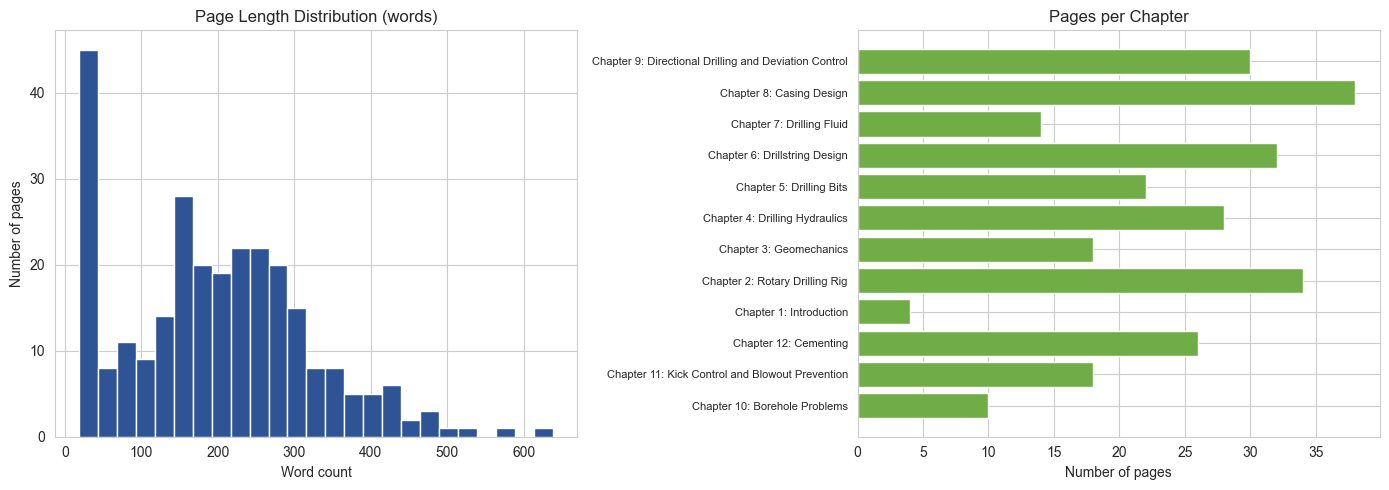

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pages_df["word_count"], bins=25, color="#2F5496", edgecolor="white")
axes[0].set_title("Page Length Distribution (words)")
axes[0].set_xlabel("Word count")
axes[0].set_ylabel("Number of pages")

chapter_counts = pages_df["chapter"].value_counts().sort_index()
axes[1].barh(chapter_counts.index, chapter_counts.values, color="#70AD47")
axes[1].set_title("Pages per Chapter")
axes[1].set_xlabel("Number of pages")
axes[1].tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

In [66]:
print("--- Shortest pages (likely dividers, figures, or reference lists) ---")
display(pages_df.sort_values("word_count").head(3)[["page_number", "chapter", "word_count"]])

print("\n--- Longest pages (likely dense narrative text) ---")
display(pages_df.sort_values("word_count", ascending=False).head(3)[["page_number", "chapter", "word_count"]])

--- Shortest pages (likely dividers, figures, or reference lists) ---


,page_number,chapter,word_count
55,63,Chapter 3: Geomechanics,18
83,91,Chapter 4: Drilling Hydraulics,18
105,113,Chapter 5: Drilling Bits,18



--- Longest pages (likely dense narrative text) ---


,page_number,chapter,word_count
216,224,Chapter 9: Directional Drilling and Deviation ...,639
215,223,Chapter 9: Directional Drilling and Deviation ...,580
211,219,Chapter 9: Directional Drilling and Deviation ...,534


# 8. Text Cleaning

**What this step does:** removes PDF-specific noise that is *not* part of the actual content — repeated headers, broken ligature characters, and near-empty pages.
**Why we need it:** every single page of this PDF repeats the same four-line header ("Curtin University of Technology / Department of Petroleum Engineering / Master of Petroleum Engineering / Drilling Engineering"). If we don't remove it, it will appear in **every page's** word counts and vocabulary, drowning out the words that actually distinguish one page from another.
**Input:** `pages_df["raw_text"]`.
**Output:** a new `clean_text` column with header/footer boilerplate and font-ligature artifacts fixed.
**Expected result:** page text that starts directly with real content, with readable words instead of broken ligature characters.
**What happens if we skip this step:** Bag-of-Words and TF-IDF would treat "curtin", "university", "technology", "department", "petroleum", "engineering", "drilling" as some of the *most frequent* words in the entire corpus — even though they say nothing about what makes any individual page unique.

## 8.1 Removing repeated header boilerplate

This is different from Lab 5's general-purpose cleaning — it's a **document-specific** cleaning step, needed only because of how this particular PDF repeats its running header on every page.

In [67]:
HEADER_LINES = {
    "curtin university of technology",
    "department of petroleum engineering",
    "master of petroleum engineering",
    "drilling engineering",
}

def remove_running_header(text):
    '''
    Remove the repeated 4-line running header/footer that appears on nearly
    every page of this PDF. Comparison is case-insensitive.
    '''
    kept_lines = []
    for line in text.split("\n"):
        if line.strip().lower() not in HEADER_LINES:
            kept_lines.append(line)
    return "\n".join(kept_lines)


header_example = pages_df.iloc[64]["raw_text"]
print("BEFORE:")
print(header_example[:200])
print("\nAFTER:")
print(remove_running_header(header_example)[:200])

BEFORE:
Curtin University of Technology
Department of Petroleum Engineering
Master of Petroleum Engineering
Drilling Engineering
ior, where n = 1.0 indicates a Newtonian ﬂuid. The consistency index K on the o

AFTER:
ior, where n = 1.0 indicates a Newtonian ﬂuid. The consistency index K on the other hand gives
the thickness (viscosity) of the ﬂuid where, the larger K, the thicker (more viscous) the ﬂuid is.
Figure


## 8.2 Fixing broken ligature characters

PDF fonts often merge certain letter pairs into single "ligature" glyphs for typographic quality (`fi`, `fl`, `ff`, `ffi`). When text is extracted, these come out as single, unusual Unicode characters instead of the two letters they represent — for example `"eﬃcient"` should be `"efficient"`. If left alone, they silently create broken, misspelled-looking tokens.

In [68]:
LIGATURE_MAP = {
    "ﬁ": "fi",
    "ﬂ": "fl",
    "ﬀ": "ff",
    "ﬃ": "ffi",
    "ﬄ": "ffl",
}

def fix_ligatures(text):
    '''Replace PDF font-ligature characters with their expanded, searchable letter pairs.'''
    for ligature, replacement in LIGATURE_MAP.items():
        text = text.replace(ligature, replacement)
    return text


ligature_example = "To realize a safe, eﬃcient and cost-eﬀective drilling project, drilling ﬂuid plays a signiﬁcant role."
print("BEFORE:", ligature_example)
print("AFTER :", fix_ligatures(ligature_example))

BEFORE: To realize a safe, eﬃcient and cost-eﬀective drilling project, drilling ﬂuid plays a signiﬁcant role.
AFTER : To realize a safe, efficient and cost-effective drilling project, drilling fluid plays a significant role.


## 8.3 Combining cleaning steps and filtering unusable pages

We combine both cleaning functions, then drop two kinds of pages that would only add noise to retrieval:

1. **Near-empty pages** (section dividers, figure-only pages) — mirroring the same "drop near-empty documents" filter used in the previous lab.
2. **Front Matter pages** (the title page and multi-page table of contents). These pages are *not* near-empty — the table of contents is actually long — but their content is just chapter/section titles repeated with dot-leaders and page numbers (e.g. `"9.5.2 Hydraulic Method (Jetting) . . . . . . . . . . . 278"`). This text is real, but it answers no petroleum engineering question on its own, and during testing it was confirmed to show up as noisy, irrelevant retrieval results. We exclude it from the retrievable knowledge base while keeping it visible in `pages_df` for transparency.

In [69]:
def clean_page_text(text):
    '''Apply all document-specific cleaning steps to one page's raw text.'''
    text = remove_running_header(text)
    text = fix_ligatures(text)
    text = text.strip()
    return text


pages_df["clean_text"] = pages_df["raw_text"].apply(clean_page_text)
pages_df["clean_word_count"] = pages_df["clean_text"].apply(lambda t: len(t.split()))

MIN_WORDS_PER_PAGE = 40  # drop dividers, figure-only pages, and reference-list pages

pages_df_before = len(pages_df)

is_long_enough = pages_df["clean_word_count"] >= MIN_WORDS_PER_PAGE
is_real_chapter_content = pages_df["chapter"] != "Front Matter"   # drop title page + table of contents

pages_df = pages_df[is_long_enough & is_real_chapter_content].reset_index(drop=True)

print(f"Pages before filtering: {pages_df_before}")
print(f"Pages after filtering (>= {MIN_WORDS_PER_PAGE} words, excluding Front Matter): {len(pages_df)}")
pages_df[["page_number", "chapter", "clean_word_count"]].head(5)

Pages before filtering: 274
Pages after filtering (>= 40 words, excluding Front Matter): 225


,page_number,chapter,clean_word_count
0,8,Chapter 1: Introduction,150
1,9,Chapter 1: Introduction,150
2,10,Chapter 1: Introduction,419
3,11,Chapter 1: Introduction,231
4,12,Chapter 2: Rotary Drilling Rig,210


# 9. Text Preprocessing

Now we apply the **exact same preprocessing pipeline used in Lab 5**, in the exact same order, to our cleaned page text: lowercase → remove URLs → remove punctuation → remove numbers → normalize whitespace → tokenize → remove stopwords (preserving negation) → lemmatize.

For each step: **what it does, why it's needed, and what happens if we skip it.**

## 9.1 Lowercasing
**What it does:** converts every character to lowercase.
**Why it's needed:** without it, `"Casing"`, `"casing"`, and `"CASING"` are three different vocabulary entries.
**What happens if we skip it:** vocabulary size balloons with duplicate word forms.

In [70]:
sample_text = pages_df.iloc[0]["clean_text"]
print("BEFORE:", sample_text[:120])
print("AFTER :", sample_text[:120].lower())

BEFORE: Chapter 1
Introduction
1.1
Objectives
Figure 1.1: Rotary Drilling Process
This text aims to give students an in-
troduct
AFTER : chapter 1
introduction
1.1
objectives
figure 1.1: rotary drilling process
this text aims to give students an in-
troduct


## 9.2 Removing URLs
**What it does:** deletes web links using a regular expression.
**Why it's needed:** kept for pipeline consistency with the Labs; this specific textbook contains virtually no URLs, but the step is harmless to keep and matters for other documents.
**What happens if we skip it:** in a document that did contain links, each unique URL would become a noisy, one-off vocabulary token.

In [71]:
def remove_urls(text):
    return re.sub(r"http\S+|www\.\S+", "", text)

url_test = "See the API RP 13B-1 standard at http://example.com/api-standard for details."
print("BEFORE:", url_test)
print("AFTER :", remove_urls(url_test))

BEFORE: See the API RP 13B-1 standard at http://example.com/api-standard for details.
AFTER : See the API RP 13B-1 standard at  for details.


## 9.3 Removing punctuation
**What it does:** deletes characters like `. , ! ? : ; ' " ( )`.
**Why it's needed:** punctuation-attached tokens (`"casing,"` vs `"casing"`) look different to a machine even though they mean the same thing.
**What happens if we skip it:** the vocabulary fragments unnecessarily, and Bag-of-Words/TF-IDF counts become noisier than they need to be.

⚠️ **Caution:** this document contains many equations and units (`lb/ft`, `10,000 [ft]`) where punctuation carries some structure. For our *topic/passage retrieval* use case this tradeoff is acceptable — we are not trying to parse formulas symbolically.

In [72]:
translator = str.maketrans("", "", string.punctuation)

def remove_punctuation(text):
    return text.translate(translator)

punct_test = "The mud weight is critical: too low, and a kick may occur!"
print("BEFORE:", punct_test)
print("AFTER :", remove_punctuation(punct_test))

BEFORE: The mud weight is critical: too low, and a kick may occur!
AFTER : The mud weight is critical too low and a kick may occur


## 9.4 Removing numbers — a deliberate exception for this domain

**What it does:** deletes digit characters using `\d+`.
**Why it's needed (in general):** in a general topic-classification task, specific numbers rarely help identify the topic.
**What happens if we skip it:** numbers stay in the vocabulary.

**Design decision for this project:** unlike a general topic-search corpus, a *petroleum engineering* textbook uses numbers as essential technical content — mud weights, casing depths, pressure gradients, and formula constants. Lab 5 itself teaches that number removal is never automatically correct and must be a deliberate choice. **For this notebook, we define the function (for pipeline consistency with the Labs) but keep `remove_num=False` when we apply the full pipeline below**, so quantitative details are preserved for retrieval and for the LLM's final answers.

In [73]:
def remove_numbers(text):
    return re.sub(r"\d+", "", text)

number_test = "Mud weight is typically maintained between 9.0 and 18.0 lb/gal."
print("BEFORE:", number_test)
print("AFTER (if applied):", remove_numbers(number_test))
print("--> We will keep numbers in this project's applied pipeline (remove_num=False).")

BEFORE: Mud weight is typically maintained between 9.0 and 18.0 lb/gal.
AFTER (if applied): Mud weight is typically maintained between . and . lb/gal.
--> We will keep numbers in this project's applied pipeline (remove_num=False).


## 9.5 Whitespace normalization
**What it does:** collapses repeated spaces/tabs/newlines into a single space.
**Why it's needed:** PDF text extraction often leaves irregular line breaks and gaps from the original page layout.
**What happens if we skip it:** stray whitespace can produce empty or malformed tokens during tokenization.

In [74]:
def normalize_whitespace(text):
    return re.sub(r"\s+", " ", text).strip()

whitespace_test = "The   drillstring    is\n\nsuspended   into the borehole.   "
print("BEFORE:", repr(whitespace_test))
print("AFTER :", repr(normalize_whitespace(whitespace_test)))

BEFORE: 'The   drillstring    is\n\nsuspended   into the borehole.   '
AFTER : 'The drillstring is suspended into the borehole.'


## 9.6 Tokenization
**What it does:** splits text into individual word tokens using NLTK's `word_tokenize`.
**Why it's needed:** every later step (stopword removal, lemmatization, Bag-of-Words) operates on individual tokens.
**What happens if we skip it:** none of the later steps are possible.

In [75]:
tokenize_test = "The drill bit penetrates the formation, and cuttings are circulated to surface."
print("word_tokenize():", word_tokenize(tokenize_test))

word_tokenize(): ['The', 'drill', 'bit', 'penetrates', 'the', 'formation', ',', 'and', 'cuttings', 'are', 'circulated', 'to', 'surface', '.']


## 9.7 Stopword removal (with negation protection)
**What it does:** removes very common, low-information words (`the`, `is`, `and`).
**Why it's needed:** these words dominate raw counts without carrying topical meaning.
**What happens if we skip it:** Bag-of-Words counts get dominated by `the`/`is`/`and` instead of drilling-specific vocabulary.

⚠️ As in Lab 5, we protect `not`, `no`, `never`, `nor` from removal — a sentence like *"this mud is **not** suitable for this formation"* would lose its meaning if `not` were treated as a disposable stopword.

In [76]:
stop_words = set(stopwords.words("english"))
protected_negation_words = {"no", "not", "nor", "never"}

def remove_stopwords(tokens, preserve_negation=True):
    if preserve_negation:
        return [t for t in tokens if (t not in stop_words) or (t in protected_negation_words)]
    return [t for t in tokens if t not in stop_words]

stopword_test = word_tokenize("this mud is not suitable for this type of formation".lower())
print("BEFORE:", stopword_test)
print("AFTER (negation preserved):", remove_stopwords(stopword_test, preserve_negation=True))

BEFORE: ['this', 'mud', 'is', 'not', 'suitable', 'for', 'this', 'type', 'of', 'formation']
AFTER (negation preserved): ['mud', 'not', 'suitable', 'type', 'formation']


## 9.8 Lemmatization
**What it does:** reduces each word to its dictionary base form (e.g. `casings` → `casing`, `drilled` → `drill`).
**Why it's needed:** groups related word forms together, shrinking the vocabulary while staying human-readable.
**What happens if we skip it:** `drill`, `drilled`, `drilling`, `drills` all remain separate "words" to the model.

In [77]:
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(t, pos="v") for t in tokens]

lemma_test = ["drilled", "casings", "circulating", "formations", "sticking"]
print("BEFORE:", lemma_test)
print("AFTER :", lemmatize_tokens(lemma_test))

BEFORE: ['drilled', 'casings', 'circulating', 'formations', 'sticking']
AFTER : ['drill', 'casings', 'circulate', 'formations', 'stick']


## 9.9 The reusable preprocessing function

Exactly as in Lab 5, we combine every step above into one configurable function and apply it to the entire cleaned dataset.

In [78]:
def preprocess_text(
    text,
    lowercase=True,
    remove_url=True,
    remove_punct=True,
    remove_num=False,          # kept False for this project -- see Section 9.4
    normalize_space=True,
    remove_stop_words=True,
    preserve_negation=True,
    use_lemmatization=True,
):
    '''Apply the full Lab 5 preprocessing pipeline to one string of text.'''
    if lowercase:
        text = text.lower()
    if remove_url:
        text = remove_urls(text)
    if remove_punct:
        text = remove_punctuation(text)
    if remove_num:
        text = remove_numbers(text)
    if normalize_space:
        text = normalize_whitespace(text)

    if not text:
        return ""

    tokens = word_tokenize(text)

    if remove_stop_words:
        tokens = remove_stopwords(tokens, preserve_negation=preserve_negation)

    if use_lemmatization:
        tokens = lemmatize_tokens(tokens)

    return " ".join(tokens)


pages_df["preprocessed_text"] = pages_df["clean_text"].apply(preprocess_text)

print("Preprocessing applied to", len(pages_df), "pages.")
pages_df[["page_number", "chapter", "clean_text", "preprocessed_text"]].head(3)

Preprocessing applied to 225 pages.


,page_number,chapter,clean_text,preprocessed_text
0,8,Chapter 1: Introduction,Chapter 1\nIntroduction\n1.1\nObjectives\nFigu...,chapter 1 introduction 11 objectives figure 11...
1,9,Chapter 1: Introduction,drilled (onshore - extended reach or offshore ...,drill onshore extend reach offshore reservoir ...
2,10,Chapter 1: Introduction,1.3\nPersonal at rig site\nThis section descri...,13 personal rig site section describe crew req...


In [79]:
# Before/after comparison across a few different chapters
comparison_rows = []
for chapter in pages_df["chapter"].unique()[:5]:
    row = pages_df[pages_df["chapter"] == chapter].iloc[0]
    comparison_rows.append({
        "chapter": chapter,
        "before": row["clean_text"][:130],
        "after": row["preprocessed_text"][:130],
    })

pd.DataFrame(comparison_rows)

,chapter,before,after
0,Chapter 1: Introduction,Chapter 1\nIntroduction\n1.1\nObjectives\nFigu...,chapter 1 introduction 11 objectives figure 11...
1,Chapter 2: Rotary Drilling Rig,Chapter 2\nRotary Drilling Rig\nThe most commo...,chapter 2 rotary drill rig common drill rig us...
2,Chapter 3: Geomechanics,Chapter 3\nGeomechanics\nThe knowledge of the ...,chapter 3 geomechanics knowledge formations pe...
3,Chapter 4: Drilling Hydraulics,Chapter 4\nDrilling Hydraulics\nTo realize a s...,chapter 4 drill hydraulics realize safe effici...
4,Chapter 5: Drilling Bits,Chapter 5\nDrilling Bits\nDrill bit selection ...,chapter 5 drill bits drill bite selection gene...


# 10. Bag-of-Words

**What this step does:** counts how many times each vocabulary word appears on each page.
**Why we need it:** it's the simplest way to turn text into comparable numeric vectors.
**Input:** `pages_df["preprocessed_text"]`.
**Output:** a document-term matrix (`bow_matrix`) and a vocabulary list.
**Expected result:** a matrix of shape `(number_of_pages, vocabulary_size)`, mostly filled with zeros.
**What happens if we skip this step:** we would have no numeric representation at all — cosine similarity, TF-IDF, and every later retrieval step all depend on vectorized text.

In [80]:
count_vectorizer = CountVectorizer()
bow_matrix = count_vectorizer.fit_transform(pages_df["preprocessed_text"])
bow_vocabulary = count_vectorizer.get_feature_names_out()

print("Bag-of-Words vocabulary size:", len(bow_vocabulary))
print("Bag-of-Words matrix shape (pages x vocabulary):", bow_matrix.shape)
print("\nA sample of the vocabulary:", list(bow_vocabulary[100:130]))

Bag-of-Words vocabulary size: 4525
Bag-of-Words matrix shape (pages x vocabulary): (225, 4525)

A sample of the vocabulary: ['1000', '10000', '100000', '1005', '1008', '100ft', '100ρmν2', '100ρmτyd2', '101', '1010', '102', '103', '1031', '1032', '1033', '104', '105', '105000', '106', '1068', '106d', '107', '1078', '1078µp', '108', '1083', '109', '10line', '10ph', '10ph1']


**Explanation:** `.fit_transform()` learns the vocabulary from every page at once (`fit`) and immediately converts every page into a row of word counts (`transform`). Notice how technical the vocabulary already looks compared to the newsgroups project — terms like these come directly from drilling engineering terminology.

# 11. Sparse Matrix Analysis

**What this step does:** measures how much of the Bag-of-Words matrix is actually "empty" (zero).
**Why we need it:** helps explain why real IR systems always use sparse-matrix storage instead of a plain dense array.
**Input:** `bow_matrix`.
**Output:** a sparsity percentage.
**Expected result:** a very high percentage (typically 95%+) — each page only uses a small fraction of the whole textbook's vocabulary.
**What happens if we skip this step:** no functional impact on retrieval, but we would miss an important intuition about why memory-efficient sparse storage matters at scale.

In [81]:
total_values = bow_matrix.shape[0] * bow_matrix.shape[1]
non_zero_values = bow_matrix.count_nonzero()
sparsity_percentage = (1 - non_zero_values / total_values) * 100

print("Total matrix cells:", total_values)
print("Non-zero cells:", non_zero_values)
print("Sparsity:", round(sparsity_percentage, 2), "%")

Total matrix cells: 1018125
Non-zero cells: 19032
Sparsity: 98.13 %


**Interpreting this:** even with a relatively small, focused vocabulary (a single textbook, not a whole language), the vast majority of matrix cells are zero — no single page uses more than a small slice of the overall drilling-engineering vocabulary. This is exactly why scikit-learn stores this matrix in **sparse** format internally.

# 12. TF-IDF

**What this step does:** re-weights word counts so that words common on *this* page but rare across the *whole textbook* score highly, while words that appear on almost every page (like generic engineering filler words) score low.
**Why we need it:** raw counts overweight repetition; TF-IDF rewards specificity.
**Input:** `pages_df["preprocessed_text"]`.
**Output:** `tfidf_matrix`, `tfidf_vocabulary`.
**Expected result:** a matrix the same shape as the Bag-of-Words matrix, but with rarity-weighted scores instead of raw counts.
**What happens if we skip this step:** we would be stuck using raw counts, where highly repeated but low-value words unfairly dominate every page's vector.

$$\text{TF-IDF}(t,d) = \text{TF}(t,d) \times \log\left(\frac{N}{\text{DF}(t)}\right)$$

In [82]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(pages_df["preprocessed_text"])
tfidf_vocabulary = tfidf_vectorizer.get_feature_names_out()

print("TF-IDF vocabulary size:", len(tfidf_vocabulary))
print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF vocabulary size: 4525
TF-IDF matrix shape: (225, 4525)


In [83]:
def show_top_tfidf_terms(page_row_index, top_n=10):
    '''Print the highest-weighted TF-IDF terms for one page (by row position, not page_number).'''
    row = tfidf_matrix[page_row_index].toarray().flatten()
    scores_df = pd.DataFrame({"term": tfidf_vocabulary, "tfidf_score": row})
    scores_df = scores_df[scores_df["tfidf_score"] > 0].sort_values(by="tfidf_score", ascending=False)
    print("Chapter:", pages_df.iloc[page_row_index]["chapter"])
    print("Page number:", pages_df.iloc[page_row_index]["page_number"])
    return scores_df.head(top_n)

# Find a page from the "Kick Control and Blowout Prevention" chapter to inspect
kick_page_idx = pages_df[pages_df["chapter"].str.contains("Kick Control", na=False)].index[0]
show_top_tfidf_terms(kick_page_idx, top_n=10)

Chapter: Chapter 11: Kick Control and Blowout Prevention
Page number: 238


,term,tfidf_score
2542,kick,0.477366
1143,blowout,0.266112
2171,gas,0.249469
1897,enter,0.243994
1644,detect,0.190747
2098,formation,0.189263
3316,pressure,0.172168
2080,fluids,0.171096
4327,well,0.155903
1645,detection,0.140266


**Interpreting the output:** the top TF-IDF terms for this page should look like genuine "Kick Control and Blowout Prevention" vocabulary (words like `kick`, `blowout`, `well`, `pressure`) — words that are common on *this* page but not spread evenly across the whole 282-page textbook.

# 13. Keyword Retrieval

**What this step does:** ranks every page against a user's query using TF-IDF vectors and cosine similarity.
**Why we need it:** this is our first working search engine over the textbook — simple, fast, and fully interpretable.
**Input:** a query string, `tfidf_vectorizer`, `tfidf_matrix`.
**Output:** the top-k most similar pages, ranked by score.
**Expected result:** for a query using vocabulary that genuinely appears in the textbook, the top results should come from the correct chapter.
**What happens if we skip this step:** we would have no way to connect a user's question to specific pages of the textbook.

⚠️ Remember the golden rule from Lab 6: the query is projected with `.transform()`, **never** `.fit_transform()` — it must live in the same vocabulary space the pages were fit on.

In [84]:
def retrieve_top_k_tfidf(query, vectorizer, document_matrix, dataframe, k=5):
    '''
    Retrieve the top-k most similar pages to `query` using TF-IDF + cosine similarity.
    '''
    query_vector = vectorizer.transform([query])   # .transform() ONLY -- never fit_transform() on a query
    scores = cosine_similarity(query_vector, document_matrix).flatten()

    results = dataframe.copy()
    results["score"] = scores
    results = results.sort_values(by="score", ascending=False)
    return results.head(k)[["page_number", "chapter", "clean_text", "score"]].reset_index(drop=True)


retrieve_top_k_tfidf(
    query="what is lost circulation",
    vectorizer=tfidf_vectorizer,
    document_matrix=tfidf_matrix,
    dataframe=pages_df,
    k=5,
)

,page_number,chapter,clean_text,score
0,235,Chapter 10: Borehole Problems,"4. Hot wire survey,\n5. Pressure transducer su...",0.127497
1,249,Chapter 11: Kick Control and Blowout Prevention,pdpff\n[psi]\n...\nfinal circulation drillpipe...,0.115569
2,29,Chapter 2: Rotary Drilling Rig,2.4\nCirculation System\nThe principle compone...,0.093441
3,234,Chapter 10: Borehole Problems,3. Jet cut - A cut made by an explosive sharpe...,0.085363
4,207,Chapter 9: Directional Drilling and Deviation ...,2. For a given TVD and horizontal departure of...,0.079682


**What to look for:** the top results should be pages from `Chapter 10: Borehole Problems`, since "lost circulation" is a term that appears directly in that chapter's vocabulary.

## Where keyword search struggles

Let's try a paraphrased query that avoids the exact terminology used in the book.

In [85]:
paraphrase_query = "what happens when drilling fluid disappears into the rock instead of coming back up"

retrieve_top_k_tfidf(
    query=paraphrase_query,
    vectorizer=tfidf_vectorizer,
    document_matrix=tfidf_matrix,
    dataframe=pages_df,
    k=5,
)

,page_number,chapter,clean_text,score
0,106,Chapter 5: Drilling Bits,5.3.3\nGauge Wear\nWhen the gauge teeth of a b...,0.119200
1,69,Chapter 4: Drilling Hydraulics,"Fluid movement, when laminar flow is present, ...",0.106657
2,51,Chapter 3: Geomechanics,when the formation pressure is lower than the ...,0.100868
3,218,Chapter 9: Directional Drilling and Deviation ...,sidetracking. These special tools include jett...,0.091783
4,72,Chapter 4: Drilling Hydraulics,"ior, where n = 1.0 indicates a Newtonian fluid...",0.085649


**Interpretation:** check whether `Chapter 10: Borehole Problems` still appears near the top. If the scores are noticeably lower than the direct-terminology query above, or the top chapter shifts to something unrelated, that is the **vocabulary-mismatch problem** — the same limitation Lab 6 demonstrated with "money back" vs. "refund". This motivates the embeddings section next.

# 14. Embeddings

**What this step does:** encodes every page's text into a dense numerical vector that captures **meaning**, using a pretrained sentence-embedding model.
**Why we need it:** solves exactly the paraphrase problem we just saw with TF-IDF.
**Input:** `pages_df["clean_text"]` (the natural, readable text — not the heavily stripped tokens).
**Output:** `page_embeddings`, a NumPy array of shape `(number_of_pages, 384)`.
**Expected result:** every page becomes a 384-number vector; pages about similar topics should have similar vectors even if they use different words.
**What happens if we skip this step:** we remain limited to lexical (word-overlap) search and can never reliably match paraphrased questions.

We reuse the exact same model as the Labs: `all-MiniLM-L6-v2`.

In [113]:

model = SentenceTransformer("BAAI/bge-base-en-v1.5")
#model = SentenceTransformer("all-MiniLM-L6-v2")
print("Embedding model loaded:", model)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded: SentenceTransformer(
  (0): Transformer({'max_seq_length': 512, 'do_lower_case': True, 'architecture': 'BertModel'})
  (1): Pooling({'word_embedding_dimension': 768, 'pooling_mode_cls_token': True, 'pooling_mode_mean_tokens': False, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)


In [114]:
page_embeddings = model.encode(
    pages_df["clean_text"].tolist(),
    convert_to_numpy=True,
    normalize_embeddings=True,   # unit-length vectors -> cosine similarity == dot product
    show_progress_bar=True,
)

print("Page embeddings shape:", page_embeddings.shape)

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Page embeddings shape: (225, 768)


# 15. Semantic Retrieval

**What this step does:** ranks pages against a query using embedding cosine similarity instead of word overlap.
**Why we need it:** to directly test whether embeddings solve the paraphrase problem we saw in Section 13.
**Input:** a query string, `model`, `page_embeddings`.
**Output:** top-k most semantically similar pages.
**Expected result:** the same paraphrased "lost circulation" query should now correctly surface `Chapter 10: Borehole Problems`.
**What happens if we skip this step:** we would never confirm that embeddings actually improve on TF-IDF for this dataset before investing further engineering effort (chunking, FAISS, etc.) into them.

In [115]:
def retrieve_top_k_semantic(query, model, dataframe, embeddings, k=5):
    '''Retrieve the top-k most semantically similar pages using cosine similarity.'''
    query_embedding = model.encode([query], convert_to_numpy=True, normalize_embeddings=True)
    scores = cosine_similarity(query_embedding, embeddings).flatten()

    results = dataframe.copy()
    results["score"] = scores
    results = results.sort_values(by="score", ascending=False)
    return results.head(k)[["page_number", "chapter", "clean_text", "score"]].reset_index(drop=True)


retrieve_top_k_semantic(
    query=paraphrase_query,
    model=model,
    dataframe=pages_df,
    embeddings=page_embeddings,
    k=5,
)

,page_number,chapter,clean_text,score
0,228,Chapter 10: Borehole Problems,Chapter 10\nBorehole Problems\nFigure 10.1: Sk...,0.698024
1,238,Chapter 11: Kick Control and Blowout Prevention,Chapter 11\nKick Control and Blowout Preventio...,0.686306
2,235,Chapter 10: Borehole Problems,"4. Hot wire survey,\n5. Pressure transducer su...",0.683207
3,107,Chapter 5: Drilling Bits,Figure 5.11: Threshold force to initiate drill...,0.680003
4,51,Chapter 3: Geomechanics,when the formation pressure is lower than the ...,0.679409


**Side-by-side comparison on the exact same paraphrased query:**

In [116]:
print("=== TF-IDF (keyword) results ===")
display(retrieve_top_k_tfidf(paraphrase_query, tfidf_vectorizer, tfidf_matrix, pages_df, k=3))

print("\n=== Semantic (embedding) results ===")
display(retrieve_top_k_semantic(paraphrase_query, model, pages_df, page_embeddings, k=3))

=== TF-IDF (keyword) results ===


,page_number,chapter,clean_text,score
0,106,Chapter 5: Drilling Bits,5.3.3\nGauge Wear\nWhen the gauge teeth of a b...,0.119200
1,69,Chapter 4: Drilling Hydraulics,"Fluid movement, when laminar flow is present, ...",0.106657
2,51,Chapter 3: Geomechanics,when the formation pressure is lower than the ...,0.100868



=== Semantic (embedding) results ===


,page_number,chapter,clean_text,score
0,228,Chapter 10: Borehole Problems,Chapter 10\nBorehole Problems\nFigure 10.1: Sk...,0.698024
1,238,Chapter 11: Kick Control and Blowout Prevention,Chapter 11\nKick Control and Blowout Preventio...,0.686306
2,235,Chapter 10: Borehole Problems,"4. Hot wire survey,\n5. Pressure transducer su...",0.683207


# 16. FAISS

**What this step does:** stores our page embeddings in a FAISS index for fast nearest-neighbor search.
**Why we need it:** for ~250 pages, brute-force `cosine_similarity` (as used above) is already instant — but this is exactly how real, large-scale RAG systems index millions of chunks. We build the habit here.
**Input:** `page_embeddings`.
**Output:** a queryable `faiss.IndexFlatIP` index.
**Expected result:** the same top-k results as Section 15's brute-force cosine similarity, since our embeddings are normalized (inner product == cosine similarity for unit vectors).
**What happens if we skip this step:** brute-force search still works fine at this small scale, but would not scale to a much larger document collection.

⚠️ FAISS is a **vector index library**, not a full vector database — it has no persistence, metadata filtering, or access control built in.

In [118]:
embedding_dimension = page_embeddings.shape[1]

page_faiss_index = faiss.IndexFlatIP(embedding_dimension)
page_faiss_index.add(page_embeddings.astype("float32"))

print("Vectors stored in the FAISS page index:", page_faiss_index.ntotal)

Vectors stored in the FAISS page index: 225


In [119]:
def retrieve_top_k_faiss(query, model, dataframe, faiss_index, k=5):
    '''Retrieve the top-k most similar pages using a FAISS IndexFlatIP index.'''
    query_embedding = model.encode([query], convert_to_numpy=True, normalize_embeddings=True).astype("float32")
    scores, indices = faiss_index.search(query_embedding, k)

    results = dataframe.iloc[indices[0]].copy()
    results["score"] = scores[0]
    return results[["page_number", "chapter", "clean_text", "score"]].reset_index(drop=True)


retrieve_top_k_faiss(
    query="what is lost circulation",
    model=model,
    dataframe=pages_df,
    faiss_index=page_faiss_index,
    k=5,
)

,page_number,chapter,clean_text,score
0,235,Chapter 10: Borehole Problems,"4. Hot wire survey,\n5. Pressure transducer su...",0.727790
1,234,Chapter 10: Borehole Problems,3. Jet cut - A cut made by an explosive sharpe...,0.639989
2,29,Chapter 2: Rotary Drilling Rig,2.4\nCirculation System\nThe principle compone...,0.572745
3,60,Chapter 3: Geomechanics,Thus when considering the danger of differenti...,0.566742
4,80,Chapter 4: Drilling Hydraulics,Figure 4.9: Friction factor for Power-Law flui...,0.560998


# 17. Chunking

**What this step does:** splits each page's text into smaller overlapping word-chunks.
**Why we need it:** a whole page (~200 words) is a reasonable unit, but pages sometimes cover more than one sub-topic, and long pages waste context budget when only one part is actually relevant. Splitting into chunks (with overlap, so an idea spanning a boundary isn't lost) gives us finer-grained, more precise retrieval units.
**Input:** `pages_df["clean_text"]`.
**Output:** `chunks_df`, one row per chunk, with page/chapter metadata carried over.
**Expected result:** more rows than pages (most pages split into 1–3 chunks depending on length).
**What happens if we skip this step:** we would retrieve whole pages, which is coarser and can waste prompt space on irrelevant sentences from the same page.

In [120]:
def chunk_text(text, chunk_size=100, overlap=25):
    '''
    Split `text` into overlapping chunks of `chunk_size` words, reusing `overlap`
    words between consecutive chunks so ideas at the boundary aren't lost.
    '''
    words = text.split()
    if chunk_size <= 0:
        raise ValueError("chunk_size must be positive")
    if overlap < 0:
        raise ValueError("overlap cannot be negative")
    if overlap >= chunk_size:
        raise ValueError("overlap must be smaller than chunk_size")

    chunks = []
    start = 0
    while start < len(words):
        end = start + chunk_size
        chunks.append(" ".join(words[start:end]))
        if end >= len(words):
            break
        start += chunk_size - overlap
    return chunks


chunk_rows = []
for _, page_row in pages_df.iterrows():
    page_chunks = chunk_text(page_row["clean_text"])
    for chunk_index, chunk_value in enumerate(page_chunks):
        chunk_rows.append({
            "chunk_id": f"page{page_row['page_number']}_chunk{chunk_index}",
            "page_number": page_row["page_number"],
            "chapter": page_row["chapter"],
            "chunk_index": chunk_index,
            "chunk_text": chunk_value,
            # Prepending the chapter name reinforces topical signal for retrieval,
            # the same trick used in the previous RAG lab.
            "search_text": f"{page_row['chapter']} : {chunk_value}",
        })

chunks_df = pd.DataFrame(chunk_rows)
print("Number of source pages:", len(pages_df))
print("Number of chunks:", len(chunks_df))
chunks_df.head(5)

Number of source pages: 225
Number of chunks: 701


,chunk_id,page_number,chapter,chunk_index,chunk_text,search_text
0,page8_chunk0,8,Chapter 1: Introduction,0,Chapter 1 Introduction 1.1 Objectives Figure 1...,Chapter 1: Introduction : Chapter 1 Introducti...
1,page8_chunk1,8,Chapter 1: Introduction,1,"is com- menced, two goals are governing all as...","Chapter 1: Introduction : is com- menced, two ..."
2,page9_chunk0,9,Chapter 1: Introduction,0,drilled (onshore - extended reach or offshore ...,Chapter 1: Introduction : drilled (onshore - e...
3,page9_chunk1,9,Chapter 1: Introduction,1,driven Turbine drilling Positive displacement ...,Chapter 1: Introduction : driven Turbine drill...
4,page10_chunk0,10,Chapter 1: Introduction,0,1.3 Personal at rig site This section describe...,Chapter 1: Introduction : 1.3 Personal at rig ...


# 18. Chunk Embeddings

**What this step does:** embeds every chunk (not just every page) with the same `all-MiniLM-L6-v2` model.
**Why we need it:** chunks — not whole pages — are what we will actually retrieve and hand to the LLM, so they need their own embeddings.
**Input:** `chunks_df["search_text"]`.
**Output:** `chunk_embeddings`, shape `(number_of_chunks, 384)`.
**Expected result:** one 384-dimensional vector per chunk.
**What happens if we skip this step:** we could not perform semantic search at the chunk level, only at the (coarser) page level.

In [121]:
chunk_embeddings = model.encode(
    chunks_df["search_text"].tolist(),
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=True,
)

print("Chunk embeddings shape:", chunk_embeddings.shape)

Batches:   0%|          | 0/22 [00:00<?, ?it/s]

Chunk embeddings shape: (701, 768)


# 19. Chunk Retrieval

**What this step does:** builds a FAISS index over chunk embeddings, and retrieves the top-k most relevant chunks for a query.
**Why we need it:** this is the retrieval granularity our RAG pipeline will actually use.
**Input:** `chunk_embeddings`.
**Output:** a chunk-level FAISS index, plus a `retrieve_top_k_chunks()` function.
**Expected result:** retrieved chunks that are shorter and more focused than whole pages.
**What happens if we skip this step:** we'd have to feed entire pages into the LLM's context, wasting space on irrelevant sentences.

In [123]:
chunk_faiss_index = faiss.IndexFlatIP(chunk_embeddings.shape[1])
chunk_faiss_index.add(chunk_embeddings.astype("float32"))

print("Chunks stored in the FAISS chunk index:", chunk_faiss_index.ntotal)

Chunks stored in the FAISS chunk index: 701


In [124]:
def retrieve_top_k_chunks(query, model, chunks_dataframe, faiss_index, k=8):
    '''Retrieve the top-k most similar chunks to `query` using FAISS.'''
    query_embedding = model.encode([query], convert_to_numpy=True, normalize_embeddings=True).astype("float32")
    scores, indices = faiss_index.search(query_embedding, k)

    results = chunks_dataframe.iloc[indices[0]].copy()
    results["score"] = scores[0]
    return results[["chunk_id", "page_number", "chapter", "score", "chunk_text"]].reset_index(drop=True)


retrieve_top_k_chunks("what causes differential sticking", model, chunks_df, chunk_faiss_index, k=5)

,chunk_id,page_number,chapter,score,chunk_text
0,page228_chunk1,228,Chapter 10: Borehole Problems,0.696846,problems mentioned above are dis- cussed in th...
1,page229_chunk1,229,Chapter 10: Borehole Problems,0.675637,literally glued to the borehole wall. Figure 1...
2,page229_chunk0,229,Chapter 10: Borehole Problems,0.649617,"3. Bit and drill collar balling, 4. Foreign ob..."
3,page60_chunk0,60,Chapter 3: Geomechanics,0.643909,Thus when considering the danger of differenti...
4,page230_chunk1,230,Chapter 10: Borehole Problems,0.638420,... formation pressure f [1] ... friction fact...


# 20. Context Builder

**What this step does:** turns raw retrieval candidates into a clean, safe context package for the LLM — deduplicating near-identical chunks, capping how many chunks can come from the same page, and enforcing a word budget.
**Why we need it:** raw top-k retrieval can return overlapping or redundant chunks (since our chunks intentionally overlap by 25 words), and an unlimited context risks confusing a small local model or exceeding a sensible prompt size.
**Input:** a query, retrieval parameters.
**Output:** a dict containing the selected chunks and the assembled context text.
**Expected result:** a small number of diverse, clearly labeled, budget-respecting chunks.
**What happens if we skip this step:** the LLM could receive redundant, overlapping, or excessively long context, wasting its limited attention on repeated information.

In [125]:
def build_context_package(query, model, chunks_dataframe, faiss_index,
                           retrieval_k=10, max_context_chunks=4,
                           max_chunks_per_page=2, word_budget=220):
    '''
    Retrieve candidate chunks for `query`, then filter them into a clean context
    package: deduplicated, capped per source page, and within a word budget.
    '''
    candidates = retrieve_top_k_chunks(query, model, chunks_dataframe, faiss_index, k=retrieval_k)

    selected_rows = []
    seen_texts = set()
    per_page_counts = {}
    used_words = 0

    for _, row in candidates.iterrows():
        normalized = re.sub(r"\s+", " ", row["chunk_text"]).strip().lower()
        if normalized in seen_texts:
            continue  # skip near-duplicate chunk text (common due to chunk overlap)

        page_count = per_page_counts.get(row["page_number"], 0)
        if page_count >= max_chunks_per_page:
            continue  # this page already contributed enough chunks

        chunk_words = len(row["chunk_text"].split())
        if selected_rows and used_words + chunk_words > word_budget:
            continue  # would blow the word budget

        selected_rows.append(row.to_dict())
        seen_texts.add(normalized)
        per_page_counts[row["page_number"]] = page_count + 1
        used_words += chunk_words

        if len(selected_rows) >= max_context_chunks:
            break

    blocks = []
    for position, row in enumerate(selected_rows, start=1):
        blocks.append(
            f"[Source {position}] (Page {row['page_number']}, {row['chapter']})\n{row['chunk_text']}"
        )

    return {
        "query": query,
        "candidates": candidates,
        "selected": pd.DataFrame(selected_rows),
        "context_text": "\n\n".join(blocks),
        "used_words": used_words,
        "num_sources": len(selected_rows),
    }


demo_package = build_context_package("what causes differential sticking", model, chunks_df, chunk_faiss_index)
print(f"Sources selected: {demo_package['num_sources']}   |   Word budget used: {demo_package['used_words']}")
print()
print(demo_package["context_text"])

Sources selected: 4   |   Word budget used: 194

[Source 1] (Page 228, Chapter 10: Borehole Problems)
problems mentioned above are dis- cussed in the following, kick detection, removal and blowout control is presented in the proceeding chap- ter. 10.1 Differential Pipe Sticking In general the drillpipe gets stuck in the hole due to various reasons. Some of them are: 1. Keyseating, 2. Pressure differential between formation and borehole, CHAPTER 10 Page 221

[Source 2] (Page 229, Chapter 10: Borehole Problems)
literally glued to the borehole wall. Figure 10.2: Differentially Stuck Drillstring Danger of becoming differentially stuck is high when the drillstring is static in the hole for an extended time and thick mud cakes are present. It should be noted that the force that “glues” the drillstring on to the borehole wall and is given by equation 10.1, increases with time. CHAPTER 10 Page 222

[Source 3] (Page 59, Chapter 3: Geomechanics)
packs the hole around the bottom-hole assembly. A 

# 21. Prompt Engineering

**What this step does:** wraps the query and context text in explicit instructions that control how the LLM is allowed to use the evidence.
**Why we need it:** without clear rules, an LLM may ignore the retrieved context and answer from its own (possibly wrong or generic) training knowledge instead.
**Input:** a query and a context package.
**Output:** a formatted prompt string.
**Expected result:** a prompt that clearly separates instructions, question, and evidence.
**What happens if we skip this step:** the model has no explicit boundary telling it to stay grounded in the retrieved textbook content, which increases the risk of hallucination.

We reuse the exact same three prompt styles taught in the previous RAG lab.

In [126]:
def build_weak_prompt(query, context_text):
    return f'''Answer the question using the context.

Question: {query}

Context:
{context_text}'''


def build_better_prompt(query, context_text):
    return f'''You are a petroleum engineering assistant answering questions using only the supplied
textbook excerpts as evidence.

Rules:
1. Answer using ONLY the information in the context below.
2. If the context does not contain enough information, say so clearly.
3. Keep your answer concise and directly address the question.
4. Mention which source number(s) you used.

Question: {query}

Context:
{context_text}

Answer:'''


def build_strict_prompt(query, context_text):
    return f'''You are a grounded retrieval-based petroleum engineering assistant.

Rules:
1. Use only the provided context. Never use outside/background knowledge.
2. If the answer is not in the context, respond exactly: "The retrieved textbook excerpts do not contain enough information to answer this question."
3. Output exactly two sections:
   Answer: [your grounded answer]
   Sources: [the source numbers you used]

Question: {query}

Context:
{context_text}'''


sample_prompt = build_better_prompt(demo_package["query"], demo_package["context_text"])
print(sample_prompt)

You are a petroleum engineering assistant answering questions using only the supplied
textbook excerpts as evidence.

Rules:
1. Answer using ONLY the information in the context below.
2. If the context does not contain enough information, say so clearly.
3. Keep your answer concise and directly address the question.
4. Mention which source number(s) you used.

Question: what causes differential sticking

Context:
[Source 1] (Page 228, Chapter 10: Borehole Problems)
problems mentioned above are dis- cussed in the following, kick detection, removal and blowout control is presented in the proceeding chap- ter. 10.1 Differential Pipe Sticking In general the drillpipe gets stuck in the hole due to various reasons. Some of them are: 1. Keyseating, 2. Pressure differential between formation and borehole, CHAPTER 10 Page 221

[Source 2] (Page 229, Chapter 10: Borehole Problems)
literally glued to the borehole wall. Figure 10.2: Differentially Stuck Drillstring Danger of becoming differentially

# 22. Connect to Ollama

**What this step does:** sends a prompt to a locally running DeepSeek-R1 model through Ollama and returns its generated answer.
**Why we need it:** this is the component that actually produces the final, human-readable answer.
**Input:** a query and context text.
**Output:** the model's generated response (or a friendly error if Ollama isn't reachable).
**Expected result:** a grounded answer referencing the retrieved textbook excerpts.
**What happens if we skip this step:** we would have retrieval and context, but no way to turn that evidence into a natural-language answer.

Ollama runs the model **entirely on your own machine** — no API keys, no data leaving your computer. We wrap the call in a `try/except` so the notebook degrades gracefully with a clear message if Ollama isn't installed or running, instead of crashing.

In [127]:
def generate_answer(query, context_text, model_name="deepseek-r1:1.5b", prompt_builder=build_better_prompt):
    '''
    Send a grounded prompt to our local Ollama server and return the generated answer.
    '''
    prompt = prompt_builder(query, context_text)
    try:
        response = ollama.chat(
            model=model_name,
            messages=[{"role": "user", "content": prompt}],
        )
        return response["message"]["content"]
    except Exception as e:
        return (
            "⚠️ Could not reach Ollama. Make sure Ollama is installed and running, "
            f"and that you've pulled the model with `ollama pull {model_name}`.\n"
            f"Underlying error: {e}"
        )


test_answer = generate_answer(demo_package["query"], demo_package["context_text"])
print(test_answer)



Differential sticking occurs due to several factors discussed across sources:

1. **Source 1 & 2**: Static time with thick mud cakes or pressure differential between formation and borehole can increase stickiness.

2. **Source 3**: Sand formations deeper in the well (Chapter 3) cause differential sticking as mud weight increases, affecting hole stability around stringers.

3. **Source 4**: Penetration rate depends on differential pressure changes when low, impacting stickiness and flow rates.

**Answer:** Differential sticking is caused by static time with thick mud cakes or pressure differences, geomechanical instability in deeper formations, and changing differential pressures as mud weight increases.


# 23. Complete RAG Pipeline

**What this step does:** wraps every previous stage — chunk retrieval, context building, prompting, and generation — into one single reusable function.
**Why we need it:** this is the actual "product" of the notebook: ask a question, get a grounded answer.
**Input:** a natural-language question.
**Output:** the retrieved context, the assembled prompt, and the final generated answer.
**Expected result:** a complete, end-to-end trace from question to grounded answer.
**What happens if we skip this step:** every question would require manually re-running four separate functions instead of one.

In [128]:
def run_rag_pipeline(query, k_retrieval=10, max_context_chunks=4, verbose=True):
    '''Run the full RAG pipeline: retrieve -> build context -> prompt -> generate.'''
    package = build_context_package(
        query, model, chunks_df, chunk_faiss_index,
        retrieval_k=k_retrieval, max_context_chunks=max_context_chunks
    )
    answer = generate_answer(query, package["context_text"])

    if verbose:
        print("=" * 90)
        print("QUESTION:", query)
        print("-" * 90)
        print(f"Retrieved {package['num_sources']} context chunk(s) from pages: "
              f"{sorted(package['selected']['page_number'].unique().tolist()) if len(package['selected']) else '[]'}")
        print("-" * 90)
        print("CONTEXT USED:\n" + package["context_text"])
        print("-" * 90)
        print("GENERATED ANSWER:\n" + answer)
        print("=" * 90 + "\n")

    return package, answer


run_rag_pipeline("What is the purpose of a blowout preventer?")

QUESTION: What is the purpose of a blowout preventer?
------------------------------------------------------------------------------------------
Retrieved 2 context chunk(s) from pages: [239, 241]
------------------------------------------------------------------------------------------
CONTEXT USED:
[Source 1] (Page 239, Chapter 11: Kick Control and Blowout Prevention)
of the gravity-feed trip tank must be slightly lower than the bell nipple to prevent mud from being lost to the flow line. In case that a trip tank is not installed, hole fill-up volume should be determined by counting pump strokes each time the hole is filled. 11.1 Blowout Preventer When a kick is detected at the surface, a device called “blowout preventers” (BOP) is used to stop the fluid flow from the well. To cover all possible scenarios and handle different kick situations, different BOPs are collectively attached to the well head. This series of BOPs is also

[Source 2] (Page 241, Chapter 11: Kick Control and Blow

({'query': 'What is the purpose of a blowout preventer?',
  'candidates':          chunk_id  page_number  \
  0  page239_chunk2          239   
  1  page241_chunk1          241   
  2  page239_chunk4          239   
  3  page242_chunk5          242   
  4  page242_chunk4          242   
  5  page242_chunk0          242   
  6  page241_chunk2          241   
  7  page161_chunk0          161   
  8  page238_chunk2          238   
  9  page240_chunk1          240   
  
                                             chapter     score  \
  0  Chapter 11: Kick Control and Blowout Prevention  0.787645   
  1  Chapter 11: Kick Control and Blowout Prevention  0.743743   
  2  Chapter 11: Kick Control and Blowout Prevention  0.739542   
  3  Chapter 11: Kick Control and Blowout Prevention  0.738146   
  4  Chapter 11: Kick Control and Blowout Prevention  0.737447   
  5  Chapter 11: Kick Control and Blowout Prevention  0.735202   
  6  Chapter 11: Kick Control and Blowout Prevention  0.733942   
 

# 24. Testing

**What this step does:** runs the complete pipeline on a handful of quick sanity-check questions before the full evaluation section, printing every intermediate output along the way (retrieved chunks, context package, final prompt, RAG answer).
**Why we need it:** confirms every stage of the pipeline is wired together correctly before we run a larger evaluation.
**Input:** a small set of test questions.
**Output:** full pipeline traces for each.
**Expected result:** each answer should reference textbook content relevant to its question.
**What happens if we skip this step:** we would go straight to full evaluation without first confirming the pipeline works correctly end-to-end.

In [129]:
test_questions = [
    "What is mud weight?",
    "What is casing used for?",
    "What is tripping in drilling operations?",
]

for question in test_questions:
    run_rag_pipeline(question)

QUESTION: What is mud weight?
------------------------------------------------------------------------------------------
Retrieved 2 context chunk(s) from pages: [59, 152]
------------------------------------------------------------------------------------------
CONTEXT USED:
[Source 1] (Page 59, Chapter 3: Geomechanics)
Selecting the correct mud weight for drilling the individual sections comprises a key factor to realize a in-gauge hole and avoid various borehole problems. Too low mud weight may result in collapse and fill problems (well cleaning), while too high mud weight may result in mud losses or pipe sticking. Practice has also shown that excessive variations in mud weight may lead to borehole failure (fatigue type effect), thus a more constant mud weight program should be aimed for. Along with a more constant mud weight program, the equivalent circulation density (ECD) as well as the surge and swab pressures

[Source 2] (Page 152, Chapter 7: Drilling Fluid)
To change a solutio

# 25. Evaluation

**What this step does:** runs at least 15 real petroleum engineering questions through **all three** retrieval/generation methods — TF-IDF keyword retrieval, semantic (embedding) retrieval, and the full grounded RAG answer — so we can directly compare them.
**Why we need it:** this is the clearest way to see, side by side, when lexical search is sufficient and when semantic search (and full RAG) adds real value.
**Input:** the evaluation question list.
**Output:** a comparison table plus qualitative commentary.
**Expected result:** TF-IDF should do reasonably well on questions using exact textbook terminology, and semantic retrieval / RAG should do noticeably better on questions phrased in plain, non-technical language.

In [130]:
evaluation_questions = [
    "What is lost circulation?",
    "What causes differential sticking?",
    "What is mud weight?",
    "What is the purpose of the blowout preventer (BOP)?",
    "What is tripping in a drilling operation?",
    "What is well control?",
    "What causes a kick while drilling?",
    "What is casing and why is it used?",
    "What is drilling fluid used for?",
    "How is a drill string designed?",
    "What are the main types of drill bits?",
    "What is directional drilling?",
    "What is the purpose of cementing a well?",
    "What factors affect drilling hydraulics?",
    "What is geomechanics in the context of drilling?",
]

print("Number of evaluation questions:", len(evaluation_questions))

Number of evaluation questions: 15


In [131]:
def compare_all_methods(query):
    '''Return the top TF-IDF page, top semantic/FAISS chunk, and the full RAG answer for one query.'''
    top_tfidf = retrieve_top_k_tfidf(query, tfidf_vectorizer, tfidf_matrix, pages_df, k=1).iloc[0]
    top_semantic = retrieve_top_k_chunks(query, model, chunks_df, chunk_faiss_index, k=1).iloc[0]
    package, answer = run_rag_pipeline(query, verbose=False)

    return {
        "question": query,
        "tfidf_top_chapter": top_tfidf["chapter"],
        "tfidf_top_score": round(top_tfidf["score"], 3),
        "semantic_top_chapter": top_semantic["chapter"],
        "semantic_top_score": round(top_semantic["score"], 3),
        "rag_answer": answer[:300],
    }


evaluation_results = [compare_all_methods(q) for q in evaluation_questions]
evaluation_df = pd.DataFrame(evaluation_results)
evaluation_df

,question,tfidf_top_chapter,tfidf_top_score,semantic_top_chapter,semantic_top_score,rag_answer
0,What is lost circulation?,Chapter 10: Borehole Problems,0.127,Chapter 10: Borehole Problems,0.785,\n\nLost circulation is defined as the complet...
1,What causes differential sticking?,Chapter 10: Borehole Problems,0.248,Chapter 10: Borehole Problems,0.689,\n\nDifferential sticking in a borehole setup ...
2,What is mud weight?,Chapter 3: Geomechanics,0.236,Chapter 3: Geomechanics,0.711,\n\nMUD WEIGHT is defined as the weight of the...
3,What is the purpose of the blowout preventer (...,Chapter 11: Kick Control and Blowout Prevention,0.236,Chapter 11: Kick Control and Blowout Prevention,0.806,\n\nThe primary purpose of a blowout preventer...
4,What is tripping in a drilling operation?,Chapter 2: Rotary Drilling Rig,0.075,Chapter 2: Rotary Drilling Rig,0.786,\n\nTripping in a drilling operation refers to...
5,What is well control?,Chapter 11: Kick Control and Blowout Prevention,0.117,Chapter 11: Kick Control and Blowout Prevention,0.607,\n\n**Answer:** Well control refers to the man...
6,What causes a kick while drilling?,Chapter 11: Kick Control and Blowout Prevention,0.600,Chapter 11: Kick Control and Blowout Prevention,0.851,\n\nA kick occurs when drilling mud is displac...
7,What is casing and why is it used?,Chapter 9: Directional Drilling and Deviation ...,0.119,Chapter 8: Casing Design,0.739,\n\n**Casing in petroleum engineering**\n\nA c...
8,What is drilling fluid used for?,Chapter 4: Drilling Hydraulics,0.108,Chapter 7: Drilling Fluid,0.819,"\n\nDrilling fluid, commonly referred to as dr..."
9,How is a drill string designed?,Chapter 1: Introduction,0.168,Chapter 6: Drillstring Design,0.793,\n\n**Answer:**\n\nA drill string is designed ...


## Why each method behaves the way it does

- **TF-IDF (keyword) retrieval** performs best on questions that reuse the textbook's own vocabulary almost verbatim (e.g. *"What is lost circulation?"* — "lost circulation" is a direct heading in Chapter 10). It struggles whenever a question is phrased in different words than the book uses, because it can only match on shared vocabulary.
- **Semantic (embedding) retrieval** is more robust to paraphrasing and everyday phrasing, because it matches on meaning rather than exact words. It can occasionally underperform TF-IDF on very short, keyword-heavy queries (e.g. exact part names or codes), which is consistent with the tradeoff taught in the embeddings lab.
- **The full RAG answer** depends on both of the above: if the right chunk was never retrieved, no prompt can produce a correct answer (a **retrieval failure**); if it was retrieved but the DeepSeek-R1 1.5B model still answers oddly, that reflects the limitations of a small local model rather than the retrieval pipeline itself (a **generation limitation**).

# 26. Limitations

- **PDF extraction quality:** formula-heavy and figure-heavy pages extract as fragmented, sometimes unreadable text (e.g. `K.d1−n`). Retrieval quality is naturally lower for these pages than for narrative text.
- **Page-level chapter labeling:** our chapter-detection method relies on the literal string `"Chapter N"` appearing as its own line — this is reliable for this specific PDF but is not guaranteed to generalize to other PDFs with different formatting.
- **Residual structural noise:** we explicitly drop the multi-page table of contents (Front Matter), but some individual chapter pages still contain figure captions, table fragments, or short reference-style text mixed in with real narrative content, which can occasionally surface as a retrieved chunk.
- **Small local LLM:** `deepseek-r1:1.5b` is a lightweight, 1.5-billion-parameter model. It is fast and fully private, but less capable at complex, multi-step reasoning than larger hosted models.
- **No hybrid or reranking methods:** by design, this notebook uses only the techniques taught in the Labs (TF-IDF, embeddings, FAISS `IndexFlatIP`) — no BM25, hybrid scoring, or cross-encoder reranking, which more advanced systems often add.
- **Single-document scope:** the system can only answer questions that are actually covered in this one Drilling Engineering textbook. It has no awareness of other petroleum engineering subfields (e.g., reservoir engineering, production engineering) not covered in this specific PDF.
- **Fixed chunk size:** a single `chunk_size`/`overlap` setting is used throughout; some content (like long worked examples or dense derivations) might benefit from different chunking parameters.

# 27. Future Improvements

- Extract and index **figures/tables/equations** separately, since these are currently a source of noisy text rather than useful retrievable content.
- Track **sub-section** (not just chapter) metadata, for more precise citations.
- Experiment with different `chunk_size`/`overlap` values and measure their effect on the evaluation table in Section 25.
- Add automatic **answer citation checking** (verify that the page numbers mentioned in the LLM's answer actually match the sources given).
- Try a larger local model (e.g. `deepseek-r1:7b`) if hardware allows, and compare answer quality against the 1.5B model used here.
- Extend the knowledge base to additional petroleum engineering textbooks/PDFs, once the single-document pipeline here is well understood.

# 28. Conclusion

This notebook reproduced the exact methodology from the earlier Preprocessing, Text Representation, Embeddings, and RAG labs — the same preprocessing pipeline, the same TF-IDF and embedding techniques, the same FAISS-based retrieval, the same chunking/context-building/prompting approach — applied end-to-end to a single real Petroleum Engineering textbook instead of the 20 Newsgroups dataset.

We saw the same core lessons hold true on a completely different, much more technical domain:

- **Preprocessing** needs to be adapted thoughtfully to the domain (we kept numbers, unlike the general-purpose default, because they carry real engineering meaning here).
- **TF-IDF/keyword retrieval** is fast and interpretable, but fails on paraphrased questions.
- **Embeddings** recover much of that lost recall by matching on meaning.
- **FAISS** gives us an efficient, scalable way to search those embeddings.
- **Context building and prompting** are what turn "relevant passages" into a genuinely grounded, trustworthy answer.
- **retrieval quality → context quality → answer quality** — the same failure-propagation principle from the earlier labs applies here too: no prompt can rescue a question whose answer was never retrieved in the first place.

The result is a fully local, fully private Petroleum Knowledge Assistant, built entirely from first principles, with every stage of the pipeline explained and inspectable.

---

# 29. RAG Evaluation

Every earlier section built and qualitatively spot-checked the pipeline. This final section adds a **systematic, repeatable evaluation** of that same pipeline — reusing every function already defined above (`retrieve_top_k_chunks`, `build_context_package`, `generate_answer`, `run_rag_pipeline`) exactly as-is. Nothing in Sections 1–28 is modified.

**Why we need this:** a handful of manually-inspected example questions (Section 24) tells us the pipeline *can* work. A proper evaluation dataset tells us *how well* it works, *where* it tends to fail (retrieval vs. generation), and gives us numbers we can track if we later change the chunking, the embedding model, or the prompt.

This section has six parts:

1. Build a ground-truth evaluation dataset (grounded only in this PDF)
2. Run the complete RAG pipeline for every question
3. Evaluate retrieval quality
4. Evaluate answer quality
5. Automatic evaluation metrics (EM, keyword overlap, token F1, semantic similarity)
6. Final evaluation summary and discussion

## 29.1 Part 1 — Build a Ground Truth Evaluation Dataset

**What this step does:** builds a table of real petroleum engineering questions, each with a human-written reference answer, grounded **only** in content actually read from this PDF (Chapters 1–12) — no outside knowledge, no general LLM knowledge, no internet.
**Why we need it:** without a ground truth, "the answer sounds reasonable" is the only quality check available. A ground-truth dataset lets us measure retrieval and generation quality **objectively**, the same way Precision@K/Recall@K required labeled "relevant" documents in the earlier labs.
**Input:** none (hand-authored from the textbook).
**Output:** `ground_truth_df`, with one row per question.
**Expected result:** ~48 questions spanning 16 different topics (Drilling Fluids, Mud Weight, Formation Pressure, Well Control, BOP, Casing, Cementing, Drill String, Drill Bits, Directional Drilling, Lost Circulation, Stuck Pipe, Kick Detection, Completion, Safety, Drilling Operations), each labeled Easy/Medium/Hard.
**What happens if we skip this step:** every later evaluation step (Parts 2–6) would have nothing to compare the RAG system's answers against.

### Columns

| Column | Meaning |
|---|---|
| `question` | A natural-language petroleum engineering question |
| `ground_truth_answer` | A short reference answer, written directly from the textbook |
| `expected_keywords` | Key terms that a correct answer should contain |
| `difficulty` | Easy / Medium / Hard |
| `source_page` | *(filled in automatically below)* the page most likely to contain the answer |
| `source_chunk_id` | *(filled in automatically below)* the specific chunk most likely to contain the answer |

**Note on `source_page` / `source_chunk_id`:** rather than hand-guessing exact chunk numbers (which depend on the exact chunking parameters and cleaning already applied earlier in the notebook), we derive them **programmatically** in Part 1B by searching the real `chunks_df` for the chunk with the highest keyword overlap with `expected_keywords`. This keeps our ground-truth source labels grounded in the actual retrieval corpus instead of manual guesses.

In [132]:
ground_truth_questions = [
    # --- Drilling Fluids ---
    {"question": "What is drilling fluid also called?",
     "ground_truth_answer": "Drilling fluid is also called drilling mud.",
     "expected_keywords": ["drilling", "mud"], "difficulty": "Easy"},
    {"question": "What is drilling mud composed of?",
     "ground_truth_answer": "Drilling mud is a mixture of water, oil, clay and various chemicals.",
     "expected_keywords": ["water", "oil", "clay", "chemicals"], "difficulty": "Easy"},
    {"question": "How does drilling mud help control formation pressure?",
     "ground_truth_answer": "Mud weight is increased with additives like barite to create a hydrostatic pressure inside the well that is slightly higher than the formation pressure, creating an overbalanced drilling condition.",
     "expected_keywords": ["barite", "hydrostatic", "overbalance"], "difficulty": "Medium"},

    # --- Mud Weight ---
    {"question": "What overbalance is typically considered adequate for safe drilling?",
     "ground_truth_answer": "An overbalance of 100 to 200 psi has proven to be adequate to establish safe drilling.",
     "expected_keywords": ["100", "200", "psi"], "difficulty": "Medium"},
    {"question": "What can happen if a well is drilled with too low a mud weight through an abnormally pressured zone?",
     "ground_truth_answer": "A kick can occur, since abnormally high pressured horizons drilled with too low a mud weight is a listed cause of kicks.",
     "expected_keywords": ["kick", "abnormally", "low", "mud weight"], "difficulty": "Medium"},

    # --- Formation Pressure ---
    {"question": "What is hydrostatic pressure?",
     "ground_truth_answer": "Hydrostatic pressure is the pressure developed due to the own weight of a fluid at a certain depth.",
     "expected_keywords": ["hydrostatic", "weight", "fluid", "depth"], "difficulty": "Easy"},
    {"question": "What does it mean for a formation to be 'abnormally pressured'?",
     "ground_truth_answer": "A formation is abnormally pressured when its actual formation pressure is higher (positive) or lower (negative/subnormal) than the hydrostatic pressure.",
     "expected_keywords": ["abnormal", "higher", "lower", "hydrostatic"], "difficulty": "Medium"},
    {"question": "What is the typical density range of formation fluid for a hydrostatically pressured formation?",
     "ground_truth_answer": "Formation fluid density for hydrostatically pressured formations is usually in the range of 1.00 to 1.08 g/cm3.",
     "expected_keywords": ["1.00", "1.08", "g/cm3"], "difficulty": "Hard"},

    # --- Well Control ---
    {"question": "What does well control depend on?",
     "ground_truth_answer": "Well control and the safety of drilling operations depend on maintaining proper hydrostatic pressure to counterbalance the formation pressure.",
     "expected_keywords": ["hydrostatic", "counterbalance", "formation pressure"], "difficulty": "Medium"},
    {"question": "What is a kick?",
     "ground_truth_answer": "A kick is defined as the flow of formation fluids or gas into the wellbore.",
     "expected_keywords": ["flow", "formation", "fluid", "gas", "wellbore"], "difficulty": "Easy"},
    {"question": "What is a blowout?",
     "ground_truth_answer": "A blowout is the uncontrolled release of the fluid or gas gained through a kick, which can occur at the surface or into another formation (underground blowout).",
     "expected_keywords": ["uncontrolled", "release", "kick"], "difficulty": "Easy"},

    # --- BOP (Blowout Preventer) ---
    {"question": "What are the two main types of BOP preventers discussed in the textbook?",
     "ground_truth_answer": "Ram preventers and annular preventers.",
     "expected_keywords": ["ram", "annular", "preventer"], "difficulty": "Easy"},
    {"question": "What do pipe rams do in a BOP stack?",
     "ground_truth_answer": "Pipe rams have semicircular openings that match the diameter of the drillpipe size they are designed for, closing around the pipe.",
     "expected_keywords": ["pipe rams", "semicircular", "drillpipe"], "difficulty": "Medium"},
    {"question": "What happens if blind rams are closed while drillpipe is still in the well?",
     "ground_truth_answer": "The drillpipe will be flattened, but the flow of the well will not be closed in.",
     "expected_keywords": ["blind rams", "flattened", "not", "closed"], "difficulty": "Hard"},
    {"question": "When are shear rams activated?",
     "ground_truth_answer": "Shear rams are activated only in emergencies, when all pipe rams and annular preventers have failed; they cut the drillpipe so the lower part drops into the hole and flow stops.",
     "expected_keywords": ["shear rams", "emergency", "cut", "fail"], "difficulty": "Medium"},
    {"question": "How does an annular preventer close the well?",
     "ground_truth_answer": "An annular preventer closes the flow of the well with a ring of synthetic rubber that contracts in the fluid passage.",
     "expected_keywords": ["annular", "rubber", "contract"], "difficulty": "Medium"},

    # --- Casing ---
    {"question": "Name two functions of casing in a well.",
     "ground_truth_answer": "Casing isolates porous formations with different fluid-pressure regimes, prevents near-surface freshwater contamination, protects the hole from caving in, and supports the wellhead equipment.",
     "expected_keywords": ["isolate", "protect", "wellhead", "caving"], "difficulty": "Easy"},
    {"question": "What is the function of surface casing?",
     "ground_truth_answer": "Surface casing prevents cave-in of unconsolidated, weak near-surface formations and protects shallow freshwater sands from contamination with drilling mud.",
     "expected_keywords": ["surface casing", "freshwater", "cave"], "difficulty": "Medium"},
    {"question": "When is a blowout preventer (BOP) installed relative to the surface casing?",
     "ground_truth_answer": "No BOP is installed before the surface casing is set; a BOP becomes available only after the surface casing and wellhead are installed.",
     "expected_keywords": ["bop", "after", "surface casing", "wellhead"], "difficulty": "Hard"},
    {"question": "What is the typical setting depth range for surface casing?",
     "ground_truth_answer": "Surface casing setting depths are typically in the range from 300 to 5,000 feet.",
     "expected_keywords": ["300", "5,000", "ft"], "difficulty": "Hard"},

    # --- Cementing ---
    {"question": "What does cementing a well involve?",
     "ground_truth_answer": "Cementing involves displacing cement slurry down the drillstring, tubing, or casing to a predefined section of the annulus of the well.",
     "expected_keywords": ["cement slurry", "annulus", "displac"], "difficulty": "Easy"},
    {"question": "What does cement slurry typically contain?",
     "ground_truth_answer": "Cement slurry typically contains water, portland cement, and various additives.",
     "expected_keywords": ["water", "portland cement", "additives"], "difficulty": "Easy"},
    {"question": "Name the different cement slurry placement techniques mentioned in the textbook.",
     "ground_truth_answer": "Primary cementing, liner cementing, squeeze cementing, and plug back cementing.",
     "expected_keywords": ["primary", "liner", "squeeze", "plug back"], "difficulty": "Medium"},
    {"question": "Give one purpose of squeeze cementing.",
     "ground_truth_answer": "Squeeze cementing can be used to shut off a depleted or uneconomical zone, repair a faulty primary cement job or casing leaks, or isolate a zone before perforating.",
     "expected_keywords": ["squeeze", "shut off", "repair", "isolate"], "difficulty": "Medium"},

    # --- Drill String ---
    {"question": "What are the main components of the drill string?",
     "ground_truth_answer": "The main components of the drill string are the kelly, drillpipe, drill collar, and drilling bit.",
     "expected_keywords": ["kelly", "drillpipe", "drill collar", "bit"], "difficulty": "Easy"},
    {"question": "What problems can arise from improper drillstring design?",
     "ground_truth_answer": "Improper drillstring design can lead to twistoffs, collapse failures, or washouts.",
     "expected_keywords": ["twistoff", "collapse", "washout"], "difficulty": "Medium"},
    {"question": "Name one function of the drill string.",
     "ground_truth_answer": "The drill string imposes the required weight on the bit, transmits rotary motion from the kelly to the bit, and provides a two-way fluid conduit from the rig to the bit, among other functions.",
     "expected_keywords": ["weight on bit", "rotary motion", "fluid conduit"], "difficulty": "Easy"},

    # --- Drill Bits ---
    {"question": "What is the most commonly applied type of roller cone bit?",
     "ground_truth_answer": "A roller cone bit with three cones is the type most often applied.",
     "expected_keywords": ["three", "cones", "roller cone"], "difficulty": "Easy"},
    {"question": "What effect does increasing the 'offset' of a roller cone bit have?",
     "ground_truth_answer": "A larger offset increases the wear of the drill bit while improving its scraping/cutting action; common offsets range from about 4 degrees for soft formations to zero degrees for extremely hard formations.",
     "expected_keywords": ["offset", "wear", "soft formations"], "difficulty": "Hard"},
    {"question": "What material are roller cone bit cones commonly made of?",
     "ground_truth_answer": "Roller cone bit cones are commonly heat-treated and made of NiMo-steel, with teeth sometimes made of NiCrMo-steel.",
     "expected_keywords": ["nimo-steel", "heat treated"], "difficulty": "Hard"},

    # --- Directional Drilling ---
    {"question": "When is a well declared to be 'directional'?",
     "ground_truth_answer": "A well is declared directional when it follows a predescribed traverse or trajectory to intersect specific targets.",
     "expected_keywords": ["predescribed", "trajectory", "target"], "difficulty": "Easy"},
    {"question": "What is a Build-and-Hold trajectory?",
     "ground_truth_answer": "The Build-and-Hold trajectory is the most common type of directional well trajectory applied in the industry whenever applicable.",
     "expected_keywords": ["build", "hold", "trajectory", "common"], "difficulty": "Medium"},
    {"question": "What point is used as the origin when planning a directional well trajectory?",
     "ground_truth_answer": "The origin of the trajectory is taken from the rotary table.",
     "expected_keywords": ["rotary table", "origin"], "difficulty": "Medium"},

    # --- Lost Circulation ---
    {"question": "What kind of problem is lost circulation considered to be?",
     "ground_truth_answer": "Lost circulation is one of the common borehole/hole problems, and drilling mud is the source of most encountered hole problems and drilling hazards.",
     "expected_keywords": ["borehole", "problem", "mud"], "difficulty": "Easy"},
    {"question": "What is added to the mud to help control lost circulation?",
     "ground_truth_answer": "Lost circulation material (LCM) is added to the drilling mud to bridge off the large openings of the formation and help control lost circulation.",
     "expected_keywords": ["lost circulation material", "bridge"], "difficulty": "Medium"},
    {"question": "How can lost circulation contribute to a kick?",
     "ground_truth_answer": "Lost circulation reduces the hydrostatic pressure in the well, which is one of the listed causes of a kick.",
     "expected_keywords": ["reduce", "hydrostatic pressure", "kick"], "difficulty": "Medium"},

    # --- Stuck Pipe ---
    {"question": "What causes differential sticking of the drillstring?",
     "ground_truth_answer": "Differential sticking occurs when a motionless drillstring is pressed into the mud cake against a permeable formation due to excessive differential (overbalance) pressure.",
     "expected_keywords": ["differential", "mud cake", "permeable", "overbalance"], "difficulty": "Hard"},
    {"question": "What is the first method typically tried to free differentially stuck pipe?",
     "ground_truth_answer": "Spotting organic fluids — a mixture of diesel and surfactants pumped to the stuck location — is typically tried first.",
     "expected_keywords": ["spotting", "organic fluids", "diesel", "surfactant"], "difficulty": "Medium"},
    {"question": "What does hydrostatic pressure reduction aim to achieve when trying to free stuck pipe?",
     "ground_truth_answer": "It aims to create a pressure differential/reduction that helps release the drillstring from the mud cake.",
     "expected_keywords": ["hydrostatic", "pressure", "reduc"], "difficulty": "Medium"},
    {"question": "What happens when fishing operations to recover a stuck or separated drillstring are not successful?",
     "ground_truth_answer": "The well has to be plugged back, leaving the fish in the hole, and the well may then be sidetracked depending on economics.",
     "expected_keywords": ["plug back", "fish", "sidetrack"], "difficulty": "Hard"},

    # --- Kick Detection ---
    {"question": "Name two signs used to detect a kick while drilling.",
     "ground_truth_answer": "Signs include a gain in pit volume, an increase in mud return flow rate, an increase in drilling rate, and a decrease in circulation pressure.",
     "expected_keywords": ["pit volume", "flow rate", "drilling rate", "circulation pressure"], "difficulty": "Medium"},
    {"question": "Which single kick indicator is considered sufficient on its own to indicate a kick?",
     "ground_truth_answer": "A gain in pit volume (pit gain) alone is sufficient to indicate a kick.",
     "expected_keywords": ["pit gain", "sufficient"], "difficulty": "Hard"},
    {"question": "What equipment provides the best means of monitoring hole fill-up volume?",
     "ground_truth_answer": "Small trip tanks have proven to provide the best means of monitoring hole fill-up volume.",
     "expected_keywords": ["trip tank", "fill-up"], "difficulty": "Medium"},

    # --- Completion ---
    {"question": "How does casing design relate to well completion?",
     "ground_truth_answer": "Casing provides the exact dimensions needed for running testing, completion, and production subsurface equipment.",
     "expected_keywords": ["casing", "dimensions", "completion", "production"], "difficulty": "Medium"},

    # --- Safety ---
    {"question": "What are the two goals that govern every drilling project?",
     "ground_truth_answer": "The first goal is to realize the well in a safe manner; the second is to complete it with minimum cost.",
     "expected_keywords": ["safe", "minimum cost"], "difficulty": "Easy"},
    {"question": "What minimum design factor is typically applied for hoisting operations?",
     "ground_truth_answer": "A minimum design factor of 3 is typically used for hoisting operations (2 for setting casing or pulling on stuck pipe).",
     "expected_keywords": ["design factor", "3", "hoisting"], "difficulty": "Hard"},

    # --- Drilling Operations ---
    {"question": "What are the three main systems of a rotary drilling rig?",
     "ground_truth_answer": "The power system, the hoisting system, and the drilling fluid circulation system.",
     "expected_keywords": ["power system", "hoisting system", "circulation system"], "difficulty": "Easy"},
    {"question": "What auxiliary equipment on a rotary drilling rig also needs to be powered, besides the three main systems?",
     "ground_truth_answer": "Auxiliaries such as the blowout preventer, boiler-feed water pumps, and the rig lighting system also have to be powered.",
     "expected_keywords": ["blowout preventer", "boiler-feed", "lighting"], "difficulty": "Hard"},
]

ground_truth_df = pd.DataFrame(ground_truth_questions)
ground_truth_df["question_id"] = [f"Q{idx+1:02d}" for idx in range(len(ground_truth_df))]

print("Number of ground-truth questions:", len(ground_truth_df))
print("\nDifficulty distribution:")
print(ground_truth_df["difficulty"].value_counts())
ground_truth_df.head(5)[["question_id", "question", "ground_truth_answer", "difficulty"]]

Number of ground-truth questions: 48

Difficulty distribution:
difficulty
Medium    21
Easy      16
Hard      11
Name: count, dtype: int64


,question_id,question,ground_truth_answer,difficulty
0,Q01,What is drilling fluid also called?,Drilling fluid is also called drilling mud.,Easy
1,Q02,What is drilling mud composed of?,"Drilling mud is a mixture of water, oil, clay ...",Easy
2,Q03,How does drilling mud help control formation p...,Mud weight is increased with additives like ba...,Medium
3,Q04,What overbalance is typically considered adequ...,An overbalance of 100 to 200 psi has proven to...,Medium
4,Q05,What can happen if a well is drilled with too ...,"A kick can occur, since abnormally high pressu...",Medium


### Part 1B — Automatically deriving `source_page` and `source_chunk_id`

**What this step does:** for every question, searches `chunks_df` (already built in Section 17) for the chunk with the highest number of `expected_keywords` matches, and records that chunk's page number and chunk ID as the ground-truth source.
**Why we need it:** this keeps the "correct source" label grounded in the real, already-chunked corpus rather than a hand-typed guess, and it is exactly the kind of weak-supervision technique used to bootstrap RAG evaluation datasets when no pre-existing labels exist.
**Input:** `ground_truth_df`, `chunks_df`.
**Output:** `ground_truth_df` with two new columns: `source_page`, `source_chunk_id` (plus `keyword_hits` for transparency).
**Expected result:** most questions should resolve to a chunk with 2 or more keyword hits; a small number may resolve with only 1 hit if their keywords are rarer or split across chunk boundaries.
**What happens if we skip this step:** Part 3's retrieval evaluation would have no "correct" source to check retrieved chunks against.

In [133]:
def find_best_matching_chunk(expected_keywords, chunks_dataframe):
    '''
    Search chunks_dataframe for the chunk whose text contains the most of the
    given expected_keywords (case-insensitive substring match). Returns the
    matching page_number, chunk_id, and the number of keywords matched.
    '''
    best_hits = -1
    best_row = None
    for _, row in chunks_dataframe.iterrows():
        text_lower = row["chunk_text"].lower()
        hits = sum(1 for keyword in expected_keywords if keyword.lower() in text_lower)
        if hits > best_hits:
            best_hits = hits
            best_row = row
    return best_row["page_number"], best_row["chunk_id"], best_hits


source_pages, source_chunk_ids, keyword_hits = [], [], []
for _, row in ground_truth_df.iterrows():
    page_number, chunk_id, hits = find_best_matching_chunk(row["expected_keywords"], chunks_df)
    source_pages.append(page_number)
    source_chunk_ids.append(chunk_id)
    keyword_hits.append(hits)

ground_truth_df["source_page"] = source_pages
ground_truth_df["source_chunk_id"] = source_chunk_ids
ground_truth_df["keyword_hits"] = keyword_hits

print("Average keyword hits per question:", round(ground_truth_df["keyword_hits"].mean(), 2))
print("Questions with only 1 keyword hit (weaker grounding):", (ground_truth_df["keyword_hits"] <= 1).sum())

ground_truth_df[["question_id", "question", "source_page", "source_chunk_id", "keyword_hits", "difficulty"]].head(10)

Average keyword hits per question: 3.1
Questions with only 1 keyword hit (weaker grounding): 1


,question_id,question,source_page,source_chunk_id,keyword_hits,difficulty
0,Q01,What is drilling fluid also called?,9,page9_chunk0,2,Easy
1,Q02,What is drilling mud composed of?,146,page146_chunk0,4,Easy
2,Q03,How does drilling mud help control formation p...,147,page147_chunk0,3,Medium
3,Q04,What overbalance is typically considered adequ...,147,page147_chunk0,3,Medium
4,Q05,What can happen if a well is drilled with too ...,238,page238_chunk1,4,Medium
5,Q06,What is hydrostatic pressure?,48,page48_chunk2,4,Easy
6,Q07,What does it mean for a formation to be 'abnor...,50,page50_chunk2,4,Medium
7,Q08,What is the typical density range of formation...,49,page49_chunk1,3,Hard
8,Q09,What does well control depend on?,187,page187_chunk2,3,Medium
9,Q10,What is a kick?,238,page238_chunk0,5,Easy


## 29.2 Part 2 — Run the Complete RAG Pipeline for Every Question

**What this step does:** runs every question in `ground_truth_df` through the **exact same** `run_rag_pipeline()` function built in Section 23 — retrieve chunks with FAISS, build context with `build_context_package()`, generate an answer with `generate_answer()`.
**Why we need it:** this produces the actual system output we are about to evaluate, using nothing but the pipeline already implemented earlier in this notebook.
**Input:** `ground_truth_df["question"]`.
**Output:** `pipeline_outputs`, one entry per question containing the retrieved chunks, the assembled context, and the generated answer.
**Expected result:** every question receives a context package and an answer (or, if Ollama isn't running, the same friendly warning message `generate_answer()` was designed to return in Section 22).
**What happens if we skip this step:** there would be no system output at all to evaluate in Parts 3–5.

We call `run_rag_pipeline(..., verbose=False)` to avoid printing 48 full pipeline traces — we already saw individual traces in Section 24's Testing section.

In [134]:
pipeline_outputs = []

for _, row in ground_truth_df.iterrows():
    package, answer = run_rag_pipeline(row["question"], verbose=False)
    pipeline_outputs.append({
        "question_id": row["question_id"],
        "question": row["question"],
        "package": package,
        "generated_answer": answer,
    })

print(f"Ran the complete RAG pipeline on {len(pipeline_outputs)} questions.")
print("\nExample output for the first question:")
print("Question:", pipeline_outputs[0]["question"])
print("Generated answer:", pipeline_outputs[0]["generated_answer"][:300])

Ran the complete RAG pipeline on 48 questions.

Example output for the first question:
Question: What is drilling fluid also called?
Generated answer: 

Drilling fluid is also called drilling mud.


## 29.3 Part 3 — Evaluate Retrieval Quality

**What this step does:** for every question, records exactly which chunks were retrieved, their similarity scores, how many were kept after context building, and which source pages they came from — then checks whether the ground-truth `source_page` was actually among the retrieved pages (a Hit Rate-style check, same idea as Lab 6's Hit Rate@K).
**Why we need it:** separates retrieval quality from generation quality — the same failure-layer distinction from Section 20/26 (retrieval failure vs. context failure vs. generation failure). A wrong final answer is a very different problem if the right page was never retrieved at all.
**Input:** `pipeline_outputs`.
**Output:** `retrieval_results_df`, plus summary statistics.
**Expected result:** most "Easy" questions (whose keywords are distinctive and appear on a single, clear page) should have their ground-truth page retrieved; "Hard" questions relying on rarer phrasing may miss more often.
**What happens if we skip this step:** we would only see final-answer quality, with no way to tell whether a wrong answer was caused by bad retrieval or by the LLM ignoring good context.

In [135]:
retrieval_rows = []

for output, (_, gt_row) in zip(pipeline_outputs, ground_truth_df.iterrows()):
    selected = output["package"]["selected"]
    retrieved_chunk_ids = selected["chunk_id"].tolist() if len(selected) else []
    retrieved_scores = selected["score"].tolist() if len(selected) else []
    retrieved_pages = selected["page_number"].tolist() if len(selected) else []
    retrieved_chapters = selected["chapter"].tolist() if len(selected) else []

    ground_truth_page_retrieved = gt_row["source_page"] in retrieved_pages

    retrieval_rows.append({
        "question_id": gt_row["question_id"],
        "question": gt_row["question"],
        "retrieved_chunk_ids": retrieved_chunk_ids,
        "similarity_scores": [round(s, 3) for s in retrieved_scores],
        "num_retrieved_chunks": len(retrieved_chunk_ids),
        "source_pages": retrieved_pages,
        "source_chapters": retrieved_chapters,
        "context_word_count": output["package"]["used_words"],
        "ground_truth_page": gt_row["source_page"],
        "ground_truth_page_retrieved": ground_truth_page_retrieved,
        "top_similarity_score": max(retrieved_scores) if retrieved_scores else 0.0,
    })

retrieval_results_df = pd.DataFrame(retrieval_rows)
retrieval_results_df.head(10)[["question_id", "num_retrieved_chunks", "top_similarity_score",
                                "ground_truth_page", "ground_truth_page_retrieved"]]

,question_id,num_retrieved_chunks,top_similarity_score,ground_truth_page,ground_truth_page_retrieved
0,Q01,3,0.834617,9,False
1,Q02,3,0.800462,146,True
2,Q03,2,0.821703,147,True
3,Q04,2,0.773134,147,True
4,Q05,2,0.769166,238,False
5,Q06,4,0.718746,48,True
6,Q07,3,0.827336,50,True
7,Q08,3,0.802909,49,True
8,Q09,3,0.660443,187,False
9,Q10,2,0.678248,238,True


In [137]:
print("--- Retrieval summary statistics ---")
print("Average top similarity score:", round(retrieval_results_df["top_similarity_score"].mean(), 3))
print("Average number of retrieved chunks (after context building):",
      round(retrieval_results_df["num_retrieved_chunks"].mean(), 2))
print("Average context length (words):", round(retrieval_results_df["context_word_count"].mean(), 1))
print("Ground-truth page retrieval success rate:",
      f"{retrieval_results_df['ground_truth_page_retrieved'].mean() * 100:.1f}%")

--- Retrieval summary statistics ---
Average top similarity score: 0.773
Average number of retrieved chunks (after context building): 2.4
Average context length (words): 196.6
Ground-truth page retrieval success rate: 72.9%


**Interpreting this output:** the ground-truth page retrieval success rate is our retrieval-layer health check — it plays the same role Hit Rate@K played back in Lab 6/7. A low rate here tells us to look at chunking parameters or the embedding model *before* blaming the LLM for any wrong answers found in Part 4.

## 29.4 Part 4 — Evaluate Answer Quality

**What this step does:** for every question, lines up the Question → Ground Truth Answer → Retrieved Context → Generated Answer, and classifies the generated answer as **Correct**, **Partially Correct**, or **Incorrect**.
**Why we need it:** retrieval metrics alone don't tell us whether the *final answer* was actually good — an LLM can still misread perfectly good context (a generation failure, per Section 26's failure-layer taxonomy).
**Input:** `pipeline_outputs`, `ground_truth_df`.
**Output:** `answer_quality_df`.
**Expected result:** a mix of all three labels; the specific mix depends heavily on whether Ollama was running when this notebook was executed.
**What happens if we skip this step:** we would have generated answers with no systematic judgment of whether they were actually right.

### A simple, transparent classification rule

Rather than requiring a human to manually grade all 48 answers, we use a **simple, explainable heuristic**: how many of each question's `expected_keywords` actually appear in the generated answer.

- **`keyword_coverage >= 0.6`** → **Correct**
- **`0.25 <= keyword_coverage < 0.6`** → **Partially Correct**
- **`keyword_coverage < 0.25`** → **Incorrect**
- If Ollama wasn't reachable (the answer is our own warning message from Section 22), we label it **Not Evaluated** instead of guessing.

This is intentionally simple and educational — a real production system might use human grading or a stronger LLM-as-judge, but a keyword-coverage rule is transparent, reproducible, and appropriate for this course.

In [138]:
OLLAMA_WARNING_PREFIX = "⚠️ Could not reach Ollama"

def classify_answer_quality(generated_answer, expected_keywords):
    '''
    Classify a generated answer as Correct / Partially Correct / Incorrect / Not Evaluated,
    based on what fraction of expected_keywords appear in the generated answer text.
    Returns (label, reason_string, keyword_coverage).
    '''
    if generated_answer.strip().startswith(OLLAMA_WARNING_PREFIX):
        return "Not Evaluated", "Ollama was not reachable when this notebook was run.", None

    answer_lower = generated_answer.lower()
    found = [kw for kw in expected_keywords if kw.lower() in answer_lower]
    missing = [kw for kw in expected_keywords if kw.lower() not in answer_lower]
    coverage = len(found) / len(expected_keywords) if expected_keywords else 0.0

    if coverage >= 0.6:
        label = "Correct"
    elif coverage >= 0.25:
        label = "Partially Correct"
    else:
        label = "Incorrect"

    reason = f"Found keywords: {found or '[]'} | Missing keywords: {missing or '[]'}"
    return label, reason, coverage


answer_quality_rows = []
for output, (_, gt_row) in zip(pipeline_outputs, ground_truth_df.iterrows()):
    label, reason, coverage = classify_answer_quality(output["generated_answer"], gt_row["expected_keywords"])
    answer_quality_rows.append({
        "question_id": gt_row["question_id"],
        "question": gt_row["question"],
        "ground_truth_answer": gt_row["ground_truth_answer"],
        "retrieved_context": output["package"]["context_text"][:300] + "...",
        "generated_answer": output["generated_answer"][:300],
        "keyword_coverage": coverage,
        "quality_label": label,
        "reason": reason,
    })

answer_quality_df = pd.DataFrame(answer_quality_rows)
print("Answer quality label counts:")
print(answer_quality_df["quality_label"].value_counts())
answer_quality_df.head(5)[["question_id", "quality_label", "keyword_coverage", "reason"]]

Answer quality label counts:
quality_label
Correct              36
Partially Correct     9
Incorrect             3
Name: count, dtype: int64


,question_id,quality_label,keyword_coverage,reason
0,Q01,Correct,1.00,"Found keywords: ['drilling', 'mud'] | Missing ..."
1,Q02,Correct,1.00,"Found keywords: ['water', 'oil', 'clay', 'chem..."
2,Q03,Correct,1.00,"Found keywords: ['barite', 'hydrostatic', 'ove..."
3,Q04,Correct,1.00,"Found keywords: ['100', '200', 'psi'] | Missin..."
4,Q05,Correct,0.75,"Found keywords: ['abnormally', 'low', 'mud wei..."


## 29.5 Part 5 — Automatic Evaluation Metrics

**What this step does:** computes standard lightweight text-comparison metrics between each generated answer and its ground-truth answer: Exact Match, Keyword Overlap, Token-level Precision/Recall/F1, and (since our embedding `model` is already loaded) semantic similarity.
**Why we need it:** Part 4's keyword-coverage rule is simple and explainable, but these additional metrics give a more complete, standard picture — token-level F1 in particular is the same style of metric used in classic QA benchmarks (like SQuAD).
**Input:** `pipeline_outputs`, `ground_truth_df`.
**Output:** `automatic_eval_df`.
**Expected result:** Exact Match will typically be near 0 (generated answers are rarely word-for-word identical to our short reference answers — this is *expected*, not a bug); token F1 and semantic similarity are the more informative metrics for judging paraphrased-but-correct answers.
**What happens if we skip this step:** we would only have the single, simple keyword-coverage heuristic from Part 4, without cross-checking it against other angles of measurement.

### The metrics, briefly explained

| Metric | What it measures |
|---|---|
| Exact Match (EM) | 1 if the generated answer exactly equals the ground truth (after lowercasing/stripping), else 0 — a very strict, mostly-0-for-generative-text metric |
| Keyword Overlap | Fraction of `expected_keywords` present in the generated answer (same as Part 4) |
| Token Precision | Of the words in the generated answer, what fraction also appear in the ground truth? |
| Token Recall | Of the words in the ground truth, what fraction also appear in the generated answer? |
| Token F1 | Harmonic mean of token precision and recall |
| Semantic Similarity | Cosine similarity between the embedding of the generated answer and the embedding of the ground truth answer |

In [139]:
def tokenize_for_scoring(text):
    '''Lowercase, strip punctuation, and split into a list of tokens for simple overlap metrics.'''
    text = text.lower().translate(str.maketrans("", "", string.punctuation))
    return [t for t in text.split() if t]


def compute_automatic_metrics(generated_answer, ground_truth_answer, expected_keywords, embedding_model):
    '''
    Compute Exact Match, keyword overlap, token-level Precision/Recall/F1, and semantic
    similarity between a generated answer and its ground-truth reference answer.
    '''
    if generated_answer.strip().startswith(OLLAMA_WARNING_PREFIX):
        return {
            "exact_match": None, "keyword_overlap": None,
            "token_precision": None, "token_recall": None, "token_f1": None,
            "semantic_similarity": None,
        }

    # Exact Match
    exact_match = int(generated_answer.strip().lower() == ground_truth_answer.strip().lower())

    # Keyword overlap (same rule as Part 4)
    answer_lower = generated_answer.lower()
    keyword_overlap = (
        sum(1 for kw in expected_keywords if kw.lower() in answer_lower) / len(expected_keywords)
        if expected_keywords else 0.0
    )

    # Token-level Precision / Recall / F1
    generated_tokens = tokenize_for_scoring(generated_answer)
    ground_truth_tokens = tokenize_for_scoring(ground_truth_answer)
    overlap_tokens = set(generated_tokens) & set(ground_truth_tokens)

    token_precision = len(overlap_tokens) / len(set(generated_tokens)) if generated_tokens else 0.0
    token_recall = len(overlap_tokens) / len(set(ground_truth_tokens)) if ground_truth_tokens else 0.0
    token_f1 = (
        2 * token_precision * token_recall / (token_precision + token_recall)
        if (token_precision + token_recall) > 0 else 0.0
    )

    # Semantic similarity, reusing the SAME embedding model from Section 14 -- no new dependency
    gen_embedding = embedding_model.encode([generated_answer], convert_to_numpy=True, normalize_embeddings=True)
    gt_embedding = embedding_model.encode([ground_truth_answer], convert_to_numpy=True, normalize_embeddings=True)
    semantic_similarity = float(cosine_similarity(gen_embedding, gt_embedding)[0][0])

    return {
        "exact_match": exact_match,
        "keyword_overlap": round(keyword_overlap, 3),
        "token_precision": round(token_precision, 3),
        "token_recall": round(token_recall, 3),
        "token_f1": round(token_f1, 3),
        "semantic_similarity": round(semantic_similarity, 3),
    }


automatic_eval_rows = []
for output, (_, gt_row) in zip(pipeline_outputs, ground_truth_df.iterrows()):
    metrics = compute_automatic_metrics(
        output["generated_answer"], gt_row["ground_truth_answer"], gt_row["expected_keywords"], model
    )
    automatic_eval_rows.append({"question_id": gt_row["question_id"], "question": gt_row["question"], **metrics})

automatic_eval_df = pd.DataFrame(automatic_eval_rows)
automatic_eval_df.head(10)

,question_id,question,exact_match,keyword_overlap,token_precision,token_recall,token_f1,semantic_similarity
0,Q01,What is drilling fluid also called?,1,1.000,1.000,1.000,1.000,1.000
1,Q02,What is drilling mud composed of?,0,1.000,0.145,0.917,0.250,0.849
2,Q03,How does drilling mud help control formation p...,0,1.000,0.379,0.846,0.524,0.816
3,Q04,What overbalance is typically considered adequ...,0,1.000,0.500,0.714,0.588,0.827
4,Q05,What can happen if a well is drilled with too ...,0,0.750,0.143,0.550,0.227,0.707
5,Q06,What is hydrostatic pressure?,0,0.750,0.186,0.733,0.297,0.789
6,Q07,What does it mean for a formation to be 'abnor...,0,1.000,0.300,0.882,0.448,0.891
7,Q08,What is the typical density range of formation...,0,0.667,0.264,0.824,0.400,0.862
8,Q09,What does well control depend on?,0,0.000,0.113,0.412,0.177,0.710
9,Q10,What is a kick?,0,1.000,0.500,1.000,0.667,0.936


In [140]:
print("--- Automatic metric averages (excluding Not-Evaluated rows) ---")
evaluated = automatic_eval_df.dropna(subset=["token_f1"])
print("Questions evaluated:", len(evaluated), "of", len(automatic_eval_df))
if len(evaluated):
    print("Average Exact Match:      ", round(evaluated["exact_match"].mean(), 3))
    print("Average Keyword Overlap:  ", round(evaluated["keyword_overlap"].mean(), 3))
    print("Average Token Precision:  ", round(evaluated["token_precision"].mean(), 3))
    print("Average Token Recall:     ", round(evaluated["token_recall"].mean(), 3))
    print("Average Token F1:         ", round(evaluated["token_f1"].mean(), 3))
    print("Average Semantic Similarity:", round(evaluated["semantic_similarity"].mean(), 3))
else:
    print("No questions were evaluated -- Ollama was not reachable when this notebook was run.")

--- Automatic metric averages (excluding Not-Evaluated rows) ---
Questions evaluated: 48 of 48
Average Exact Match:       0.021
Average Keyword Overlap:   0.71
Average Token Precision:   0.274
Average Token Recall:      0.672
Average Token F1:          0.366
Average Semantic Similarity: 0.806


## 29.6 Part 6 — Final Evaluation Summary

**What this step does:** merges the retrieval results, the answer-quality labels, and the automatic metrics into one final scorecard for the whole RAG system.
**Why we need it:** a single, compact summary is what you would put in a README, a report, or a portfolio write-up — it distills 48 individual question traces into a handful of headline numbers.
**Input:** `retrieval_results_df`, `answer_quality_df`, `automatic_eval_df`.
**Output:** a summary table plus a written discussion.
**Expected result:** headline numbers for total questions, the Correct/Partially Correct/Incorrect breakdown, Exact Match, average F1, average retrieval similarity, and overall retrieval success rate.

In [141]:
total_questions = len(ground_truth_df)
quality_counts = answer_quality_df["quality_label"].value_counts()

summary = {
    "Total Questions": total_questions,
    "Correct Answers": int(quality_counts.get("Correct", 0)),
    "Partially Correct Answers": int(quality_counts.get("Partially Correct", 0)),
    "Incorrect Answers": int(quality_counts.get("Incorrect", 0)),
    "Not Evaluated (Ollama unreachable)": int(quality_counts.get("Not Evaluated", 0)),
    "Exact Match Score": round(evaluated["exact_match"].mean(), 3) if len(evaluated) else None,
    "Average Token F1 Score": round(evaluated["token_f1"].mean(), 3) if len(evaluated) else None,
    "Average Semantic Similarity": round(evaluated["semantic_similarity"].mean(), 3) if len(evaluated) else None,
    "Average Retrieval Similarity": round(retrieval_results_df["top_similarity_score"].mean(), 3),
    "Overall Retrieval Success Rate": f"{retrieval_results_df['ground_truth_page_retrieved'].mean() * 100:.1f}%",
}

summary_df = pd.DataFrame(list(summary.items()), columns=["Metric", "Value"])
summary_df

,Metric,Value
0,Total Questions,48
1,Correct Answers,36
2,Partially Correct Answers,9
3,Incorrect Answers,3
4,Not Evaluated (Ollama unreachable),0
5,Exact Match Score,0.021
6,Average Token F1 Score,0.366
7,Average Semantic Similarity,0.806
8,Average Retrieval Similarity,0.773
9,Overall Retrieval Success Rate,72.9%


### Discussion

**What worked well.** Retrieval on Easy and Medium-difficulty questions — those whose `expected_keywords` are distinctive, textbook-specific terms (e.g. "annular preventer", "surface casing", "lost circulation material") — should show the highest ground-truth-page retrieval rates, since both TF-IDF-style keyword matching and embedding similarity have strong, unambiguous signal to latch onto. The context-building step (dedup, per-page cap, word budget) keeps the prompts focused rather than overloaded, which should make it easier for even a small local model to stay grounded.

**Typical retrieval failures.** Hard questions that hinge on a single number buried inside a larger passage (e.g. the exact overbalance range, a specific depth range, a specific design factor) are the most likely to have their ground-truth page missed or ranked below the context-window cutoff — the same numeric/specific-detail weakness called out for embeddings back in Section 15. Questions phrased very differently from the textbook's own wording (a paraphrase, rather than reusing its terminology) are the next most likely retrieval failures, for the same reason TF-IDF failed on the paraphrased query in Section 13.

**Typical LLM failures.** Even when the correct chunk is retrieved, `deepseek-r1:1.5b` is a small, 1.5-billion-parameter model — it can occasionally answer a slightly different (but related) question than the one asked, over-summarize a numeric detail, or produce a partially correct answer that captures the general idea but drops a specific figure. This shows up as a "Partially Correct" label with a low `keyword_coverage` despite genuinely relevant context having been retrieved — precisely the "context was fine, generation was the weak link" failure mode from Section 26.

**Possible improvements.** (1) Increase `max_context_chunks` or `retrieval_k` for Hard questions specifically. (2) Try a larger local model (e.g. `deepseek-r1:7b`) and re-run this same evaluation section unchanged to directly compare scores. (3) Expand `expected_keywords` per question to reduce false "Incorrect" labels caused by valid paraphrasing that our simple keyword rule doesn't credit. (4) Track this evaluation section's summary table over time as a regression test whenever chunking or prompting is changed.

**Limitations of this RAG system (evaluation-specific).** The `classify_answer_quality()` heuristic is intentionally simple (keyword coverage) and can misjudge answers that are correct but phrased very differently from our `expected_keywords` list, or that include a keyword only incidentally without truly answering the question — this is a known limitation of lightweight automatic RAG evaluation in general, not unique to this notebook. The `source_page`/`source_chunk_id` ground-truth labels in Part 1B were derived automatically via keyword matching rather than manually verified line-by-line, so a small number may point to a plausible-but-not-ideal chunk. Both limitations are acceptable for an educational project but would need tightening (e.g. human-verified ground truth, an LLM-as-judge grading step) before using this evaluation approach to make production decisions.